# 0. Загрузка и предобработка данных

In [1]:
from pathlib import Path
import sys
import pandas as pd

# Текущая рабочая папка — work 17.04.2026
WORK_DIR = Path.cwd()
KIT_DIR = (WORK_DIR.parent / "eeg_segments_kit").resolve()
EXPORTS_ROOT = (WORK_DIR.parent / "exports" / "exports").resolve()

if str(KIT_DIR) not in sys.path:
    sys.path.insert(0, str(KIT_DIR))

import segment_loader  # из eeg_segments_kit

print("WORK_DIR     =", WORK_DIR)
print("KIT_DIR      =", KIT_DIR)
print("EXPORTS_ROOT =", EXPORTS_ROOT)
print("KIT exists   =", KIT_DIR.exists())
print("EXPORTS_ROOT exists =", EXPORTS_ROOT.exists())


WORK_DIR     = C:\Users\Admin\Desktop\EEG\work 17.04.2026
KIT_DIR      = C:\Users\Admin\Desktop\EEG\eeg_segments_kit
EXPORTS_ROOT = C:\Users\Admin\Desktop\EEG\exports\exports
KIT exists   = True
EXPORTS_ROOT exists = True


In [2]:
# Словарь: произвольное удобное имя -> путь к папке записи (где export_manifest.json)
RECORDINGS = {
    "000":    EXPORTS_ROOT / "00000000" / "FA0183FS",
    "004":    EXPORTS_ROOT / "004" / "FA01841G",
    "005":    EXPORTS_ROOT / "005_22_03_2026" / "FA0183FS",
    "008":    EXPORTS_ROOT / "008" / "GA15011B",
    # сюда добавим позже 005_22_03_2026 / 008, когда уточним подпапки
}

for name, root in RECORDINGS.items():
    print(name, "->", root, "| exists:", root.exists())


000 -> C:\Users\Admin\Desktop\EEG\exports\exports\00000000\FA0183FS | exists: True
004 -> C:\Users\Admin\Desktop\EEG\exports\exports\004\FA01841G | exists: True
005 -> C:\Users\Admin\Desktop\EEG\exports\exports\005_22_03_2026\FA0183FS | exists: True
008 -> C:\Users\Admin\Desktop\EEG\exports\exports\008\GA15011B | exists: True


In [3]:
import pandas as pd

def has_nonempty(intervals):
    return bool(intervals) and any(float(x["end"]) > float(x["start"]) for x in intervals)

def merge_intervals(intervals):
    """
    intervals: список dict {"start": ..., "end": ...}
    Возвращает объединённые пересекающиеся/соприкасающиеся интервалы.
    """
    if not intervals:
        return []

    arr = sorted(
        [{"start": float(x["start"]), "end": float(x["end"])} for x in intervals],
        key=lambda z: z["start"]
    )

    merged = [arr[0]]
    for cur in arr[1:]:
        prev = merged[-1]
        if cur["start"] <= prev["end"] + 1e-9:
            prev["end"] = max(prev["end"], cur["end"])
        else:
            merged.append(cur)

    return merged

rows = []
recording_intervals_norm = {}

for rec_key, rec_root in RECORDINGS.items():
    man = segment_loader.load_export_manifest(rec_root)
    sfreq = float(man.get("sfreq", 0.0))
    recording_id = man.get("recording_id")

    crop_region = man.get("crop_region_global_sec")
    if crop_region and crop_region[0] is not None:
        offset = float(crop_region[0])
    else:
        tmins_tmp = []
        for idx in segment_loader.iter_segment_indices(rec_root):
            meta_tmp = segment_loader.load_segment_meta(rec_root, idx)
            tmins_tmp.append(float(meta_tmp.get("tmin_global_sec", 0.0)))
        offset = min(tmins_tmp) if tmins_tmp else 0.0

    sleep_all = []
    wake_all = []
    depd_all = []

    for idx in segment_loader.iter_segment_indices(rec_root):
        meta = segment_loader.load_segment_meta(rec_root, idx)

        tmin_global = float(meta.get("tmin_global_sec", 0.0))
        tmax_global = float(meta.get("tmax_global_sec", 0.0))

        tmin_norm = tmin_global - offset
        tmax_norm = tmax_global - offset

        sleep_int = meta.get("intervals_sleep", [])
        wake_int = meta.get("intervals_wake", [])
        depd_ch_int = meta.get("intervals_by_channel", [])
        depd_gl_int = meta.get("intervals_global", [])

        # --- сон: локальное время сегмента -> нормированное время записи
        for r in sleep_int:
            s = tmin_norm + float(r["start"])
            e = tmin_norm + float(r["end"])
            if e > s:
                sleep_all.append({"start": s, "end": e})

        # --- бодрствование
        for r in wake_int:
            s = tmin_norm + float(r["start"])
            e = tmin_norm + float(r["end"])
            if e > s:
                wake_all.append({"start": s, "end": e})

        # --- ДЭПД по каналам
        for r in depd_ch_int:
            s = tmin_norm + float(r["start"])
            e = tmin_norm + float(r["end"])
            if e > s:
                depd_all.append({
                    "start": s,
                    "end": e,
                    "channel": int(r["channel"]) if r.get("channel") is not None else None,
                    "seg": idx,
                })

        rows.append({
            "rec_key": rec_key,
            "recording_id": recording_id,
            "subject_id": meta.get("subject_id"),
            "seg": idx,
            "tmin_global": tmin_global,
            "tmax_global": tmax_global,
            "tmin_norm": tmin_norm,
            "tmax_norm": tmax_norm,
            "duration_sec": float(meta.get("duration_sec", 0.0)),
            "sfreq": float(meta.get("sfreq", sfreq)),
            "sleep": has_nonempty(sleep_int),
            "wake": has_nonempty(wake_int),
            "depd_by_ch": has_nonempty(depd_ch_int),
            "depd_global": has_nonempty(depd_gl_int),
            "n_sleep_intervals": len(sleep_int),
            "n_wake_intervals": len(wake_int),
            "n_depd_by_ch": len(depd_ch_int),
            "n_depd_global": len(depd_gl_int),
            "time_offset": offset,
        })

    # объединяем интервалы по записи уже в нормированной оси
    sleep_merged = merge_intervals(sleep_all)
    wake_merged = merge_intervals(wake_all)
    depd_merged = merge_intervals([{"start": x["start"], "end": x["end"]} for x in depd_all])

    recording_intervals_norm[rec_key] = {
        "offset": offset,
        "sleep": sleep_merged,
        "wake": wake_merged,
        "depd": depd_merged,
        "depd_raw": depd_all,   # если захочешь потом смотреть по каналам
    }

df_segments = pd.DataFrame(rows)
df_segments


,rec_key,recording_id,subject_id,seg,tmin_global,tmax_global,tmin_norm,tmax_norm,duration_sec,sfreq,sleep,wake,depd_by_ch,depd_global,n_sleep_intervals,n_wake_intervals,n_depd_by_ch,n_depd_global,time_offset
0,000,FA0183FS,00000000,0,0.000,300.000,0.0,300.000,300.000,500.0,False,True,True,False,0,1,87,0,0.000
1,000,FA0183FS,00000000,1,300.000,600.000,300.0,600.000,300.000,500.0,False,True,True,False,0,1,23,0,0.000
2,000,FA0183FS,00000000,2,600.000,900.000,600.0,900.000,300.000,500.0,False,True,True,False,0,1,31,0,0.000
3,000,FA0183FS,00000000,3,900.000,1200.000,900.0,1200.000,300.000,500.0,False,True,True,False,0,1,36,0,0.000
4,000,FA0183FS,00000000,4,1200.000,1500.000,1200.0,1500.000,300.000,500.0,False,True,True,False,0,1,35,0,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172,008,GA15011B,008,19,5710.534,6010.534,5700.0,6000.000,300.000,500.0,False,True,True,False,0,1,4,0,10.534
173,008,GA15011B,008,20,6010.534,6310.534,6000.0,6300.000,300.000,500.0,False,True,True,False,0,1,11,0,10.534
174,008,GA15011B,008,21,6310.534,6610.534,6300.0,6600.000,300.000,500.0,False,True,False,False,0,1,0,0,10.534
175,008,GA15011B,008,22,6610.534,6910.534,6600.0,6900.000,300.000,500.0,False,True,True,False,0,1,6,0,10.534


In [4]:
import numpy as np

def build_continuous_recording(rec_key, rec_root):
    """
    Собирает из всех сегментов записи один непрерывный массив EEG.
    Возвращает:
      data_all: np.ndarray (n_channels, n_samples_total)
      sfreq: float
      ch_names: list[str]
    """
    # Собираем информацию по сегментам
    seg_infos = []
    for idx in segment_loader.iter_segment_indices(rec_root):
        npz = segment_loader.load_segment_npz(rec_root, idx)
        t_start = float(npz["t_start_sec"])
        t_end = float(npz["t_end_sec"])
        data = npz["data"]          # (n_channels, n_times_segment)
        sfreq = float(npz["sfreq"])
        ch_names = [str(x) for x in npz["ch_names"].tolist()]
        seg_infos.append({
            "idx": idx,
            "t_start": t_start,
            "t_end": t_end,
            "data": data,
            "sfreq": sfreq,
            "ch_names": ch_names,
        })

    if not seg_infos:
        raise ValueError(f"Нет сегментов для записи {rec_key}")

    # Сортируем по глобальному времени начала
    seg_infos.sort(key=lambda s: s["t_start"])

    # Проверяем согласованность: одинаковый sfreq и ch_names
    base_sfreq = seg_infos[0]["sfreq"]
    base_ch_names = seg_infos[0]["ch_names"]
    n_channels = seg_infos[0]["data"].shape[0]

    for s in seg_infos[1:]:
        if abs(s["sfreq"] - base_sfreq) > 1e-6:
            raise ValueError(f"{rec_key}: Несовпадающая частота дискретизации между сегментами")
        if s["ch_names"] != base_ch_names:
            raise ValueError(f"{rec_key}: Несовпадающий список каналов между сегментами")
        if s["data"].shape[0] != n_channels:
            raise ValueError(f"{rec_key}: Несовпадающее число каналов")

    # Склеиваем по времени
    data_all = np.concatenate([s["data"] for s in seg_infos], axis=1)  # по оси времени

    return data_all, base_sfreq, base_ch_names

continuous_data = {}  # rec_key -> (data_all, sfreq, ch_names)

for rec_key, rec_root in RECORDINGS.items():
    print(f"\n=== Сборка записи {rec_key} из {rec_root} ===")
    data_all, sfreq, ch_names = build_continuous_recording(rec_key, rec_root)
    continuous_data[rec_key] = (data_all, sfreq, ch_names)
    print(
        f"rec_key={rec_key}, shape={data_all.shape}, "
        f"sfreq={sfreq}, n_channels={data_all.shape[0]}"
    )
    print("Первые каналы:", ch_names[:5])



=== Сборка записи 000 из C:\Users\Admin\Desktop\EEG\exports\exports\00000000\FA0183FS ===
rec_key=000, shape=(18, 19249128), sfreq=500.0, n_channels=18
Первые каналы: ['Fp1-F3', 'Fp2-F4', 'F3-C3', 'F4-C4', 'C3-P3']

=== Сборка записи 004 из C:\Users\Admin\Desktop\EEG\exports\exports\004\FA01841G ===
rec_key=004, shape=(18, 1708011), sfreq=500.0, n_channels=18
Первые каналы: ['Fp1-F3', 'Fp2-F4', 'F3-C3', 'F4-C4', 'C3-P3']

=== Сборка записи 005 из C:\Users\Admin\Desktop\EEG\exports\exports\005_22_03_2026\FA0183FS ===
rec_key=005, shape=(18, 1797532), sfreq=500.0, n_channels=18
Первые каналы: ['Fp1-F3', 'Fp2-F4', 'F3-C3', 'F4-C4', 'C3-P3']

=== Сборка записи 008 из C:\Users\Admin\Desktop\EEG\exports\exports\008\GA15011B ===
rec_key=008, shape=(18, 3568515), sfreq=500.0, n_channels=18
Первые каналы: ['Fp1-F3', 'Fp2-F4', 'F3-C3', 'F4-C4', 'C3-P3']


In [5]:
from collections import defaultdict

def merge_intervals(intervals, *, merge_touching=True):
    """
    intervals: список {start, end}
    Возвращает объединённые интервалы по оси времени записи.
    """
    if not intervals:
        return []

    # нормализуем и сортируем
    ivals = [
        (float(r["start"]), float(r["end"]))
        for r in intervals
        if float(r["end"]) > float(r["start"])
    ]
    ivals.sort(key=lambda x: x[0])

    merged = []
    cur_s, cur_e = ivals[0]

    for s, e in ivals[1:]:
        if merge_touching:
            # считаем [cur_s, cur_e] и [s, e] одним интервалом, если пересекаются или соприкасаются
            if s <= cur_e + 1e-9:
                cur_e = max(cur_e, e)
            else:
                merged.append({"start": cur_s, "end": cur_e})
                cur_s, cur_e = s, e
        else:
            # только если пересекаются
            if s < cur_e - 1e-9:
                cur_e = max(cur_e, e)
            else:
                merged.append({"start": cur_s, "end": cur_e})
                cur_s, cur_e = s, e

    merged.append({"start": cur_s, "end": cur_e})
    return merged


def build_intervals_for_recording_fixed(rec_key, rec_root):
    """
    Для одной записи строит:
      - интервалы сна (sleep)
      - интервалы бодрствования (wake)
      - интервалы ДЭПД (depd), объединённые по каналам
    Все интервалы в ГЛОБАЛЬНЫХ секундах от начала записи.
    """
    sleep_all = []
    wake_all = []
    depd_all = []

    for idx in segment_loader.iter_segment_indices(rec_root):
        meta = segment_loader.load_segment_meta(rec_root, idx)

        tmin_g = float(meta.get("tmin_global_sec", 0.0))
        # tmax_g = float(meta.get("tmax_global_sec", 0.0))  # при необходимости

        # Сон/бодрствование: в meta локальное время сегмента, переведём в глобальное
        for r in meta.get("intervals_sleep") or []:
            start_local = float(r["start"])
            end_local = float(r["end"])
            sleep_all.append({
                "start": tmin_g + start_local,
                "end": tmin_g + end_local,
            })

        for r in meta.get("intervals_wake") or []:
            start_local = float(r["start"])
            end_local = float(r["end"])
            wake_all.append({
                "start": tmin_g + start_local,
                "end": tmin_g + end_local,
            })

        # ДЭПД: intervals_by_channel тоже в локальном времени сегмента, вернём в глобальное
        for r in meta.get("intervals_by_channel") or []:
            start_local = float(r["start"])
            end_local = float(r["end"])
            depd_all.append({
                "start": tmin_g + start_local,
                "end": tmin_g + end_local,
                "channel": int(r["channel"]) if "channel" in r and r["channel"] is not None else None,
            })

    # Объединяем по времени (без учёта channel для депд)
    sleep_merged = merge_intervals(sleep_all)
    wake_merged = merge_intervals(wake_all)
    depd_merged = merge_intervals(
        [{"start": r["start"], "end": r["end"]} for r in depd_all]
    )

    return {
        "sleep": sleep_merged,
        "wake": wake_merged,
        "depd": depd_merged,
    }
recording_intervals_fixed = {}

for rec_key, rec_root in RECORDINGS.items():
    print(f"\n=== Интервалы (FIXED) для записи {rec_key} ===")
    ivals = build_intervals_for_recording_fixed(rec_key, rec_root)
    recording_intervals_fixed[rec_key] = ivals

    def total_duration(intervals):
        return sum(float(r["end"]) - float(r["start"]) for r in intervals)

    sleep_dur = total_duration(ivals["sleep"])
    wake_dur = total_duration(ivals["wake"])
    depd_dur = total_duration(ivals["depd"])

    print(f"  СОН:   {len(ivals['sleep'])} интервалов, суммарно ~{sleep_dur:.1f} с")
    print(f"  БДР:   {len(ivals['wake'])} интервалов, суммарно ~{wake_dur:.1f} с")
    print(f"  ДЭПД:  {len(ivals['depd'])} интервалов, суммарно ~{depd_dur:.1f} с")



=== Интервалы (FIXED) для записи 000 ===
  СОН:   6 интервалов, суммарно ~13037.8 с
  БДР:   7 интервалов, суммарно ~25460.2 с
  ДЭПД:  192 интервалов, суммарно ~68.3 с

=== Интервалы (FIXED) для записи 004 ===
  СОН:   0 интервалов, суммарно ~0.0 с
  БДР:   1 интервалов, суммарно ~3416.0 с
  ДЭПД:  460 интервалов, суммарно ~145.7 с

=== Интервалы (FIXED) для записи 005 ===
  СОН:   1 интервалов, суммарно ~2224.8 с
  БДР:   1 интервалов, суммарно ~1370.2 с
  ДЭПД:  717 интервалов, суммарно ~258.6 с

=== Интервалы (FIXED) для записи 008 ===
  СОН:   0 интервалов, суммарно ~0.0 с
  БДР:   1 интервалов, суммарно ~7137.0 с
  ДЭПД:  121 интервалов, суммарно ~202.8 с


## Текущее состояние данных и структуры проекта

1. **Структура экспортированных данных EEG**

- Для каждой записи (000, 004, 005, 008) есть отдельная папка с файлами:
  - `export_manifest.json`
  - набор сегментов `*_segXXX.npz`
  - соответствующие им `*_segXXX_meta.json`
- Каждый сегмент представляет собой ~300 секунд EEG в биполярном монтаже из 18 каналов с частотой дискретизации 500 Гц.
- Сегменты по записи идут последовательно и покрывают всю длительность исходной EEG (кроме последнего укороченного сегмента).

2. **Непрерывные массивы EEG по записям**

- С помощью функции `build_continuous_recording(rec_key, rec_root)` собраны непрерывные данные для каждой записи, склеив все сегменты по времени.
- Результат хранится в словаре `continuous_data`:
  - `continuous_data[rec_key] = (data_all, sfreq, ch_names)`
  - `data_all` — `np.ndarray` формы `(n_channels, n_samples_total)`
  - `sfreq` — частота дискретизации (500.0 Гц)
  - `ch_names` — список из 18 биполярных каналов (`Fp1-F3`, `Fp2-F4`, `F3-C3`, ...).

Полученные формы:
- `rec_key=000`: `shape=(18, 19249128)`, `sfreq=500.0`
- `rec_key=004`: `shape=(18, 1708011)`, `sfreq=500.0`
- `rec_key=005`: `shape=(18, 1797532)`, `sfreq=500.0`
- `rec_key=008`: `shape=(18, 3568515)`, `sfreq=500.0`

3. **Таблица сегментов `df_segments`**

- На основе `export_manifest.json` и `*_meta.json` построена таблица `df_segments`, где каждая строка — один 5‑минутный сегмент.
- Основные поля:
  - `rec_key` — ключ записи (`000`, `004`, `005`, `008`)
  - `recording_id`, `subject_id`
  - `seg` — индекс сегмента
  - `tmin_global`, `tmax_global` — глобальное время начала и конца сегмента (в секундах от начала записи)
  - `duration_sec` — длительность сегмента
  - `sfreq` — частота дискретизации
  - булевы флаги: `sleep`, `wake`, `depd_by_ch`, `depd_global`
  - счётчики: `n_sleep_intervals`, `n_wake_intervals`, `n_depd_by_ch`, `n_depd_global`.

Таблица `df_segments` подтверждает, что:
- по записи `000` есть 129 сегментов подряд, покрывающих всю запись;
- по записям `004`, `005`, `008` аналогично имеется набор сегментов, покрывающих всю длительность.

4. **Интервалы сна, бодрствования и ДЭПД в глобальном времени**

- Написана функция `build_intervals_for_recording_fixed(rec_key, rec_root)`, которая для каждой записи:
  - проходит по всем сегментам,
  - берёт локальные интервалы из `intervals_sleep`, `intervals_wake`, `intervals_by_channel` (внутри сегмента),
  - переводит их в глобальное время записи с учётом `tmin_global_sec`,
  - объединяет по времени пересекающиеся/соприкасающиеся интервалы (функция `merge_intervals`),
  - возвращает словарь:
    - `sleep` — список интервалов сна в глобальных секундах;
    - `wake` — список интервалов бодрствования;
    - `depd` — список интервалов ДЭПД, объединённых по всем каналам.

Для каждой записи получены такие суммарные длительности интервалов:

- **Запись 000**:
  - Сон: 6 интервалов, суммарно ~13037.8 с
  - Бодрствование: 7 интервалов, суммарно ~25460.2 с
  - ДЭПД: 192 интервала, суммарно ~68.3 с

- **Запись 004**:
  - Сон: 0 интервалов
  - Бодрствование: 1 интервал, суммарно ~3416.0 с
  - ДЭПД: 460 интервалов, суммарно ~145.7 с

- **Запись 005**:
  - Сон: 1 интервал, суммарно ~2224.8 с
  - Бодрствование: 1 интервал, суммарно ~1370.2 с
  - ДЭПД: 717 интервалов, суммарно ~258.6 с

- **Запись 008**:
  - Сон: 0 интервалов
  - Бодрствование: 1 интервал, суммарно ~7137.0 с
  - ДЭПД: 121 интервал, суммарно ~202.8 с

При этом суммарная длительность сна + бодрствования по каждой записи совпадает (с точностью до округления) с общей длительностью непрерывного сигнала `data_all.shape[1] / sfreq`. Это означает, что:
- для каждой записи ось времени непрерывна и согласована;
- разметка сна/бодрствования и ДЭПД корректно восстановлена в глобальных координатах записи.

5. **Текущая точка**

Сейчас в ноутбуке есть:
- непрерывные EEG‑массивы по каждой записи (`continuous_data`);
- таблица сегментов `df_segments` с базовой мета‑информацией по 5‑минутным кускам;
- глобальные интервалы сна, бодрствования и ДЭПД по каждой записи (`recording_intervals_fixed`).

Следующий шаг: на основе непрерывных данных и глобальных интервалов строить окна фиксированной длины (например, 0.4 с, шаг 0.1 с) отдельно для сна и бодрствования и считать для каждого окна таргет `depd_frac` — долю пересечения с интервалами ДЭПД.


In [6]:
def depd_span_for_recording_norm(rec_key):
    ivals = recording_intervals_norm[rec_key]["depd"]
    if not ivals:
        return None, None
    starts = [float(r["start"]) for r in ivals]
    ends = [float(r["end"]) for r in ivals]
    return min(starts), max(ends)

depd_spans_norm = {}
for rec_key in RECORDINGS.keys():
    t_lo, t_hi = depd_span_for_recording_norm(rec_key)
    depd_spans_norm[rec_key] = (t_lo, t_hi)
    print(f"{rec_key}: earliest DEPD (norm) = {t_lo}, latest DEPD (norm) = {t_hi}")


000: earliest DEPD (norm) = 3.676, latest DEPD (norm) = 2112.24
004: earliest DEPD (norm) = 11.847, latest DEPD (norm) = 3413.676
005: earliest DEPD (norm) = 1371.8829999999998, latest DEPD (norm) = 3594.486000000001
008: earliest DEPD (norm) = 86.81899999999999, latest DEPD (norm) = 7122.271000000001


In [7]:
trimmed_continuous_data = {}       # rec_key -> (data_trimmed, sfreq, ch_names, t_lo, t_hi)
trimmed_recording_intervals = {}   # rec_key -> dict с обрезанными sleep/wake/depd

def clip_intervals_to_span(intervals, t_lo, t_hi):
    out = []
    for r in intervals:
        s = float(r["start"])
        e = float(r["end"])
        lo = max(s, t_lo)
        hi = min(e, t_hi)
        if hi > lo:
            out.append({"start": lo, "end": hi})
    return out

for rec_key in RECORDINGS.keys():
    data_all, sfreq, ch_names = continuous_data[rec_key]
    ivals = recording_intervals_norm[rec_key]

    # span по нормированным ДЭПД
    t_lo, t_hi = depd_spans_norm[rec_key]
    if t_lo is None or t_hi is None:
        # нет ДЭПД — можно либо пропустить, либо взять всю запись как есть
        print(f"{rec_key}: нет DEPD в normalized intervals, запись не обрезаем")
        t_lo = 0.0
        t_hi = data_all.shape[1] / sfreq

    # переводим в сэмплы на нормированной оси 0–T
    start_sample = int(round(t_lo * sfreq))
    end_sample = int(round(t_hi * sfreq))
    start_sample = max(0, start_sample)
    end_sample = min(data_all.shape[1], end_sample)

    if end_sample <= start_sample:
        print(f"{rec_key}: WARNING — пустой диапазон после обрезки, пропускаем")
        trimmed_continuous_data[rec_key] = (data_all[:, :0], sfreq, ch_names, 0.0, 0.0)
        trimmed_recording_intervals[rec_key] = {"sleep": [], "wake": [], "depd": [], "span": (0.0, 0.0)}
        continue

    data_trimmed = data_all[:, start_sample:end_sample]
    t_lo_eff = start_sample / sfreq
    t_hi_eff = end_sample / sfreq

    trimmed_continuous_data[rec_key] = (data_trimmed, sfreq, ch_names, t_lo_eff, t_hi_eff)

    sleep_trim = clip_intervals_to_span(ivals["sleep"], t_lo_eff, t_hi_eff)
    wake_trim = clip_intervals_to_span(ivals["wake"], t_lo_eff, t_hi_eff)
    depd_trim = clip_intervals_to_span(ivals["depd"], t_lo_eff, t_hi_eff)

    trimmed_recording_intervals[rec_key] = {
        "sleep": sleep_trim,
        "wake": wake_trim,
        "depd": depd_trim,
        "span": (t_lo_eff, t_hi_eff),
    }

    def total_duration(intervals):
        return sum(float(r["end"]) - float(r["start"]) for r in intervals)

    print(f"\n{rec_key}: trimmed span [{t_lo_eff:.3f}, {t_hi_eff:.3f}] s")
    print(f"  sleep: {len(sleep_trim)} intervals, total ~{total_duration(sleep_trim):.1f} s")
    print(f"  wake:  {len(wake_trim)} intervals, total ~{total_duration(wake_trim):.1f} s")
    print(f"  depd:  {len(depd_trim)} intervals, total ~{total_duration(depd_trim):.1f} s")



000: trimmed span [3.676, 2112.240] s
  sleep: 0 intervals, total ~0.0 s
  wake:  1 intervals, total ~2108.6 s
  depd:  192 intervals, total ~68.3 s

004: trimmed span [11.848, 3413.676] s
  sleep: 0 intervals, total ~0.0 s
  wake:  1 intervals, total ~3401.8 s
  depd:  460 intervals, total ~145.7 s

005: trimmed span [1371.882, 3594.486] s
  sleep: 1 intervals, total ~2222.6 s
  wake:  0 intervals, total ~0.0 s
  depd:  717 intervals, total ~258.6 s

008: trimmed span [86.818, 7122.272] s
  sleep: 0 intervals, total ~0.0 s
  wake:  1 intervals, total ~7035.5 s
  depd:  121 intervals, total ~202.8 s


In [8]:
import pandas as pd

def depd_overlap_fraction(intervals, win_start, win_end):
    """
    intervals: список dict {"start", "end"} в НОРМИРОВАННЫХ секундах записи.
    win_start, win_end: границы окна в тех же координатах.
    Возвращает долю [0,1] длины окна, занятую ДЭПД.
    """
    if not intervals:
        return 0.0
    total = 0.0
    for r in intervals:
        s = float(r["start"])
        e = float(r["end"])
        lo = max(s, win_start)
        hi = min(e, win_end)
        if hi > lo:
            total += (hi - lo)
    length = win_end - win_start
    if length <= 1e-9:
        return 0.0
    frac = total / length
    return max(0.0, min(1.0, frac))


def build_windows_for_recording_subset_trimmed(
    rec_key,
    subset,       # "sleep" или "wake"
    window_sec=0.4,
    step_sec=0.1,
):
    """
    Строит окна (0.4 с, шаг 0.1) для одной записи и одного подмножества
    (сон или бодрствование), используя:
      - сигнал из trimmed_continuous_data[rec_key]
      - интервалы из trimmed_recording_intervals[rec_key]
    Возвращает DataFrame: одна строка = одно окно.
    """
    data_all, sfreq, ch_names, span_lo, span_hi = trimmed_continuous_data[rec_key]
    ivals = trimmed_recording_intervals[rec_key]

    subset_intervals = ivals[subset]    # сон или бодрствование
    depd_intervals = ivals["depd"]      # ДЭПД (объединённые интервалы), всё в нормированных секундах

    rows = []

    for seg in subset_intervals:
        seg_start = float(seg["start"])
        seg_end = float(seg["end"])

        t = seg_start
        while t + window_sec <= seg_end + 1e-9:
            win_start = t
            win_end = t + window_sec

            start_sample = int(round(win_start * sfreq))
            end_sample = int(round(win_end * sfreq))

            if end_sample > data_all.shape[1]:
                break

            depd_frac = depd_overlap_fraction(depd_intervals, win_start, win_end)

            rows.append({
                "rec_key": rec_key,
                "subset": subset,
                "start_sec": win_start,
                "end_sec": win_end,
                "start_sample": start_sample,
                "end_sample": end_sample,
                "sfreq": float(sfreq),
                "depd_frac": depd_frac,
            })

            t += step_sec

    return pd.DataFrame(rows)

windows_by_record = {}  # rec_key -> {"sleep": df, "wake": df}

for rec_key in RECORDINGS.keys():
    print(f"\n=== Генерация окон для записи {rec_key} ===")

    df_sleep = build_windows_for_recording_subset_trimmed(
        rec_key, subset="sleep", window_sec=0.4, step_sec=0.1
    )
    df_wake = build_windows_for_recording_subset_trimmed(
        rec_key, subset="wake", window_sec=0.4, step_sec=0.1
    )

    windows_by_record[rec_key] = {
        "sleep": df_sleep,
        "wake": df_wake,
    }

    print(f"  {rec_key}_sleep: {len(df_sleep)} окон")
    print(f"  {rec_key}_wake:  {len(df_wake)} окон")



=== Генерация окон для записи 000 ===
  000_sleep: 0 окон
  000_wake:  21045 окон

=== Генерация окон для записи 004 ===
  004_sleep: 0 окон
  004_wake:  33896 окон

=== Генерация окон для записи 005 ===
  005_sleep: 8504 окон
  005_wake:  0 окон

=== Генерация окон для записи 008 ===
  008_sleep: 0 окон
  008_wake:  69483 окон


In [9]:
def describe_windows(df, name):
    print(f"\n{name}:")
    if df.empty:
        print("  ПУСТОЙ датасет")
        return
    print("  windows:", len(df))
    print("  depd_frac describe:")
    print(df["depd_frac"].describe())
    print("  >0 count:", (df["depd_frac"] > 0).sum())
    print("  ==0 count:", (df["depd_frac"] == 0).sum())
    print("  >0 share:", (df["depd_frac"] > 0).mean())

df_000_wake = windows_by_record["000"]["wake"]
df_004_wake = windows_by_record["004"]["wake"]
df_005_sleep = windows_by_record["005"]["sleep"]
df_008_wake = windows_by_record["008"]["wake"]

describe_windows(df_000_wake, "000_wake")
describe_windows(df_004_wake, "004_wake")
describe_windows(df_005_sleep, "005_sleep")
describe_windows(df_008_wake, "008_wake")



000_wake:
  windows: 21045
  depd_frac describe:
count    21045.000000
mean         0.031769
std          0.139866
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: depd_frac, dtype: float64
  >0 count: 1394
  ==0 count: 19651
  >0 share: 0.06623901164172012

004_wake:
  windows: 33896
  depd_frac describe:
count    33896.000000
mean         0.042872
std          0.157124
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: depd_frac, dtype: float64
  >0 count: 3212
  ==0 count: 30684
  >0 share: 0.0947604437101723

005_sleep:
  windows: 8504
  depd_frac describe:
count    8504.000000
mean        0.063983
std         0.211190
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: depd_frac, dtype: float64
  >0 count: 974
  ==0 count: 7530
  >0 share: 0.1145343367826905

008_wake:
  windows: 69483
  depd

In [10]:
import numpy as np

def frac_bins(df, name, bins=(0.0, 0.0, 0.1, 0.5, 1.0)):
    # bins: точки раздела, интерпретируем как [0,0], (0,0.1], (0.1,0.5], (0.5,1]
    print(f"\n{name} — распределение depd_frac по диапазонам:")
    if df.empty:
        print("  ПУСТОЙ датасет")
        return
    x = df["depd_frac"].values
    mask_0 = (x == 0.0)
    mask_01 = (x > 0.0) & (x <= 0.1)
    mask_05 = (x > 0.1) & (x <= 0.5)
    mask_1 = (x > 0.5) & (x <= 1.0 + 1e-9)

    total = len(x)
    for label, m in [
        ("== 0.0", mask_0),
        ("(0.0, 0.1]", mask_01),
        ("(0.1, 0.5]", mask_05),
        ("(0.5, 1.0]", mask_1),
    ]:
        cnt = m.sum()
        print(f"  {label:10s}: {cnt:6d}  ({cnt/total:6.3%})")

frac_bins(df_000_wake, "000_wake")
frac_bins(df_004_wake, "004_wake")
frac_bins(df_005_sleep, "005_sleep")
frac_bins(df_008_wake, "008_wake")



000_wake — распределение depd_frac по диапазонам:
  == 0.0    :  19651  (93.376%)
  (0.0, 0.1]:    143  (0.679%)
  (0.1, 0.5]:    606  (2.880%)
  (0.5, 1.0]:    645  (3.065%)

004_wake — распределение depd_frac по диапазонам:
  == 0.0    :  30684  (90.524%)
  (0.0, 0.1]:    346  (1.021%)
  (0.1, 0.5]:   1550  (4.573%)
  (0.5, 1.0]:   1316  (3.882%)

005_sleep — распределение depd_frac по диапазонам:
  == 0.0    :   7530  (88.547%)
  (0.0, 0.1]:     76  (0.894%)
  (0.1, 0.5]:    423  (4.974%)
  (0.5, 1.0]:    475  (5.586%)

008_wake — распределение depd_frac по диапазонам:
  == 0.0    :  67008  (96.438%)
  (0.0, 0.1]:     85  (0.122%)
  (0.1, 0.5]:    463  (0.666%)
  (0.5, 1.0]:   1927  (2.773%)


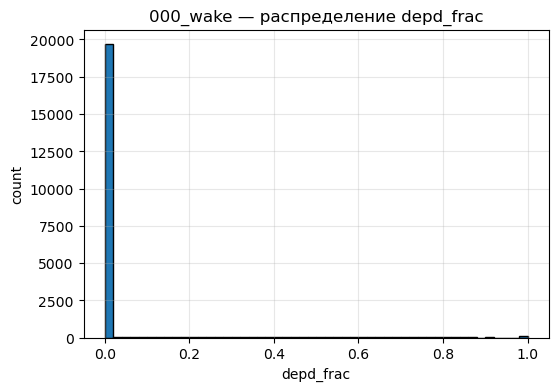

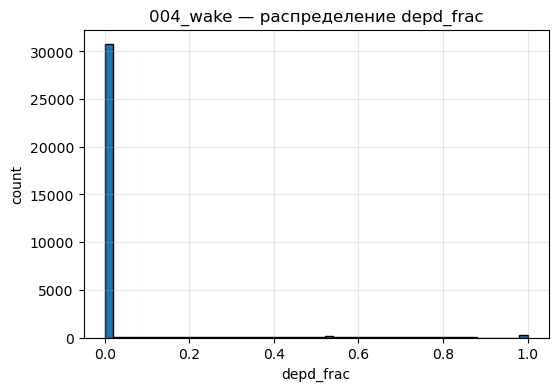

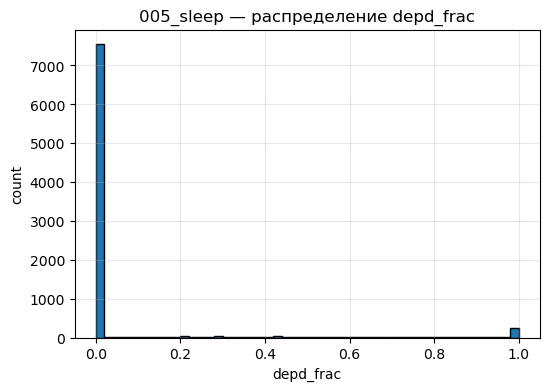

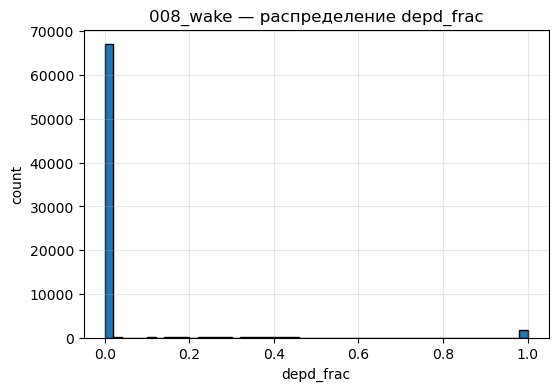

In [11]:
import matplotlib.pyplot as plt

def plot_hist(df, name, bins=50):
    if df.empty:
        print(f"{name}: пустой датасет, гистограмму не строим")
        return
    plt.figure(figsize=(6,4))
    plt.hist(df["depd_frac"], bins=bins, range=(0,1), edgecolor="k")
    plt.title(f"{name} — распределение depd_frac")
    plt.xlabel("depd_frac")
    plt.ylabel("count")
    plt.grid(alpha=0.3)
    plt.show()

plot_hist(df_000_wake, "000_wake")
plot_hist(df_004_wake, "004_wake")
plot_hist(df_005_sleep, "005_sleep")
plot_hist(df_008_wake, "008_wake")


## 1. Цель и исходные данные

В работе использовались сегменты ЭЭГ четырёх записей (`000`, `004`, `005`, `008`), выгруженные с помощью `eeg_segments_kit` и описанные через `export_manifest.json` и `*_meta.json`.[file:7][file:213]  
Задача заключалась в том, чтобы привести временные координаты к единой системе и подготовить окна 0.4 с (шаг 0.1 с) для дальнейшего обучения моделей на сон/бодрствование с маркировкой ДЭПД.[file:7][file:213]

---

## 2. Нормализация времени и исправление 005 записи

В манифестах для каждой записи есть поле `crop_region_global_sec = [t_start, t_end]`, задающее глобальные границы фрагмента исходной длинной записи, который был экспортирован.[file:7]  
Ранее глобальное время ДЭПД интерпретировалось как уже нормированное, из‑за чего для записи 005 интервалы ДЭПД оказывались за пределами её локальной длительности.  

Для исправления:

- для каждой записи вычислили `offset = crop_region_global_sec[0]` (или минимум `tmin_global_sec`, если поля нет);[file:7][file:213]  
- для каждого сегмента получили нормированные границы:
  - `tmin_norm = tmin_global_sec - offset`,  
  - `tmax_norm = tmax_global_sec - offset`;[file:7][file:213]  
- локальные интервалы в сегменте (`intervals_sleep`, `intervals_wake`, `intervals_by_channel`) перенесли в нормированную ось записи:
  - `start_norm = tmin_norm + start_local`,  
  - `end_norm = tmin_norm + end_local`.[file:7][file:213]

В результате построена структура `recording_intervals_norm[rec_key]` с интервалами сна, бодрствования и ДЭПД в координатах 0–T для каждой записи.[file:7][file:213]  
Для записи 005 первый ДЭПД‑интервал сместился с глобальных ≈10846–10849 с в нормированную ось ≈1371.88–1374.23 с и оказался внутри реальной длительности записи ≈3595 с, что подтвердило корректность нормировки.[file:7][file:6][file:213]

---

## 3. Обрезка записей по диапазону ДЭПД

Для каждой записи по нормированным интервалам ДЭПД вычислили общий span:

- `t_lo = min(start)`,  
- `t_hi = max(end)` по `recording_intervals_norm[rec_key]["depd"]`.[file:213]

Затем каждая непрерывная запись была обрезана по этому диапазону:

- сигнал `continuous_data[rec_key]` был усечён по сэмплам, соответствующим `[t_lo, t_hi]`;  
- интервалы сна/бодрствования/ДЭПД были обрезаны на этот же диапазон.[file:213]

Итоговые обрезанные интервалы (нормированная ось):

- `000`: span [3.676, 2112.240] с — только бодрствование, 68.3 с ДЭПД;[file:213]  
- `004`: span [11.848, 3413.676] с — только бодрствование, 145.7 с ДЭПД;[file:213]  
- `005`: span [1371.882, 3594.486] с — только сон, 258.6 с ДЭПД;[file:213]  
- `008`: span [86.818, 7122.272] с — только бодрствование, 202.8 с ДЭПД.[file:213]

---

## 4. Формирование окон 0.4 с / шаг 0.1 с

На обрезанных и нормированных данных были построены скользящие окна:

- размер окна: 0.4 с;  
- шаг: 0.1 с;  
- отдельно по непрерывным интервалам сна и бодрствования (`sleep` / `wake`) для каждой записи.[file:213]

Для каждого окна рассчитывалась метрика `depd_frac` — доля длительности окна, покрытая ДЭПД:

- по объединённым интервалам ДЭПД внутри записи;  
- с учётом пересечения окна и каждого интервала.[file:213]

В итоге получены четыре не пустых датасета:

- `000_wake`: 21 045 окон;[file:213]  
- `004_wake`: 33 896 окон;[file:213]  
- `005_sleep`: 8 504 окна;[file:213]  
- `008_wake`: 69 483 окна.[file:213]  

Четыре “парные” набора без соответствующей стадии (там, где не было сна или бодрствования в обрезанном интервале) оказались пустыми, как и ожидалось.[file:213]

---

## 5. Статистика и распределения `depd_frac`

По сводной статистике `depd_frac`:

- **000_wake**  
  - окон: 21 045;  
  - средний `depd_frac ≈ 0.032`, максимум 1.0;  
  - `> 0` в ~6.6 % окон (93.4 % — чистый фон).[file:213]  

- **004_wake**  
  - окон: 33 896;  
  - средний `depd_frac ≈ 0.043`;  
  - `> 0` в ~9.5 % окон (90.5 % — фон).[file:213]  

- **005_sleep**  
  - окон: 8 504;  
  - средний `depd_frac ≈ 0.064`;  
  - `> 0` в ~11.5 % окон (88.5 % — фон).[file:213]  

- **008_wake**  
  - окон: 69 483;  
  - средний `depd_frac ≈ 0.029`;  
  - `> 0` в ~3.6 % окон (96.4 % — фон).[file:213]  

Распределения по диапазонам:

- `000_wake`:  
  - 93.4 % окон с `depd_frac = 0`;  
  - 0.7 % в (0, 0.1]; 2.9 % в (0.1, 0.5]; 3.1 % в (0.5, 1.0]. [file:213]

- `004_wake`:  
  - 90.5 % окон без ДЭПД;  
  - 1.0 % в (0, 0.1]; 4.6 % в (0.1, 0.5]; 3.9 % в (0.5, 1.0]. [file:213]

- `005_sleep`:  
  - 88.5 % окон без ДЭПД;  
  - 0.9 % в (0, 0.1]; 5.0 % в (0.1, 0.5]; 5.6 % в (0.5, 1.0]. [file:213]

- `008_wake`:  
  - 96.4 % окон без ДЭПД;  
  - 0.12 % в (0, 0.1]; 0.67 % в (0.1, 0.5]; 2.77 % в (0.5, 1.0]. [file:213]

Таким образом:

- во всех наборах наблюдается ожидаемое доминирование окон без ДЭПД, что отражает редкость этих паттернов по времени;  
- наиболее насыщенным по ДЭПД является набор `005_sleep`, что соответствует клинической картине ДЭПД во сне;  
- среди бодрствующих записей `004_wake` содержит больше ДЭПД‑активности, чем `000_wake` и особенно `008_wake`, где ДЭПД редки, но часть окон с ними почти полностью заполнена эпилептиформной активностью.[file:213][web:222]


# 1. обучение

## План экспериментов по моделям для ДЭПД

### 1. Постановка задачи

Рабочий датасет состоит из окон ЭЭГ длиной 0.4 с с шагом 0.1 с, сформированных по четырём записям: `000_wake`, `004_wake`, `005_sleep`, `008_wake`.[file:213]  
Для каждого окна вычислен таргет `depd_frac` — доля длительности окна, покрытая интервалами ДЭПД в нормированной оси времени записи.[file:213]  

Основная постановка — **регрессия**:  
- вход: многоканальное окно ЭЭГ;  
- выход: число `ŷ ∈ [0, 1]`, интерпретируемое как “вероятность / степень присутствия ДЭПД в окне”.  

Для интерпретации результатов дополнительно используем **классификационный взгляд**:  
- для порогов `τ ∈ {0.2, 0.4, 0.7}` строим бинарные метки  
  - `y_true(τ) = 1`, если `depd_frac ≥ τ`, иначе 0;  
  - `y_pred(τ) = 1`, если `ŷ ≥ τ`, иначе 0.

---

### 2. Модели

Планируется сравнение нескольких типов моделей:

1. **Сверточная нейросеть (1D-CNN)**  
   - вход: сырой или нормализованный многоканальный отрезок ЭЭГ;  
   - задача: регрессия по `depd_frac` с MSE / Smooth L1 лоссом.

2. **Градиентный бустинг (например, XGBoost/LightGBM/CatBoost)**  
   - вход: hand-crafted признаки окна (энергии по частотным диапазонам, bandpower, статистики, Hjorth и т.п.);[web:230]  
   - задача: регрессия по `depd_frac`.

3. **Random Forest**  
   - та же постановка, те же признаки, что и для бустинга;[web:236]  
   - позволяет сравнить простую “нелинейную” модель без сложной настройки.

---

### 3. Работа с дисбалансом (усиление примеров с ДЭПД)

Окна без ДЭПД составляют 88–96 % от общего числа, однако они **не выбрасываются** из обучения.[file:213]  

Предлагаются стратегии:

1. **Взвешенный лосс в регрессии**  
   - базовый лосс: MSE или Smooth L1;  
   - веса:  
     - бинарный вариант: \(w_i = 1 + \alpha \cdot \mathbb{1}[\text{depd\_frac}_i > 0]\);  
     - плавный вариант: \(w_i = 1 + \alpha \cdot \text{depd\_frac}_i\).  
   - идея: окна с ДЭПД получают больший вклад в градиент, фон остаётся в обучении.

2. **Сбалансированная выборка в батчах**  
   - при формировании batch’ей гарантирутся заданная доля “позитивных” окон (например, `depd_frac > 0.1`) и остаток — нулевые окна;  
   - это уменьшает перекос градиента в сторону фона без удаления данных.[web:236][web:238]

3. **Аугментации только для окон с ДЭПД**  
   - умеренные изменения амплитуды, добавление шума, небольшой временной сдвиг окна;  
   - фон не аугментируется или аугментируется минимально, чтобы не раздувать количество однотипных примеров.

---

### 4. Метрики качества

**Регрессионные метрики:**

- MSE, MAE, R² на валидации и тесте по `depd_frac`.  

**Классификационные метрики (на основе регрессора):**

Для порогов `τ ∈ {0.2, 0.4, 0.7}`:

- построение бинарных истинных меток `y_true(τ)` по `depd_frac`;  
- бинаризация предсказаний `ŷ` порогом τ → `y_pred(τ)`;  
- расчёт: Accuracy, Precision, Recall, F1, ROC AUC, PR AUC для каждого τ.[web:233][web:236]  

Отдельно можно построить ROC/PR‑кривые по непрерывным `ŷ`, не привязываясь к конкретному порогу.

---

### 5. Эксперименты по отдельным датасетам

**E1.x — пациент-специфичные эксперименты**

Для каждой из четырёх выборок:

- `E1_000_wake`: обучение и тест только на `000_wake`;  
- `E1_004_wake`: только `004_wake`;  
- `E1_005_sleep`: только `005_sleep`;  
- `E1_008_wake`: только `008_wake`.[file:213]  

Общий протокол:

- разбиение по времени: первые ~60 % окон — train, средние ~20 % — val, последние ~20 % — test (чтобы минимизировать утечку через перекрывающиеся окна);  
- обучение CNN, бустинга и RF на регрессию `depd_frac` с учётом взвешивания;  
- оценка регрессионных и классификационных метрик (τ = 0.2, 0.4, 0.7);  
- цель: понять, насколько хорошо модели описывают ДЭПД на уровне **каждого отдельного пациента/записи**.

---

### 6. Пациент-неспецифичный эксперимент на бодрствовании

**E2 — общий awake‑датасет**

- объединённый набор бодрствования:  
  \[
  \text{awake\_all} = 000\_wake \cup 004\_wake \cup 008\_wake
  \]  
  (с сохранением информации о `rec_key` / `subject_id`).[file:213]  

Сценарии разбиения:

- вариант A: train на двух записях, test на третьей (leave-one-record-out);  
- вариант B (при расширении набора): k-fold cross-validation по пациентам.

Для каждого сценария:

- обучение CNN / бустинга / RF на `depd_frac`;  
- оценка MSE/MAE/R² и классификационных метрик по каждому τ;  
- цель: оценить обобщающую способность моделей **между разными пациентами** в бодрствовании.

---

### 7. Кросс-парадигмные эксперименты сон ↔ бодрствование

**E3 — train на сне, test на бодрствовании**

- train: `005_sleep`;  
- test: объединённый `awake_all`.  

Задача: проверить, насколько модель, увидевшая только “сонные” ДЭПД, способна детектировать эпизоды ДЭПД на бодрствовании.

---

**E4 — train на бодрствовании, test на сне**

- train: `awake_all` (000/004/008);  
- test: `005_sleep`.  

Задача: оценить переносимость “бодрствующей” модели на ночные паттерны ДЭПД.

---

**E5 — объединённый эксперимент независимо от состояния**

- train: объединение `awake_all + 005_sleep` с дополнительным флагом состояния (`is_sleep` / `is_awake`);  
- test: либо тот же mix с разбиением по пациентам, либо отложенная запись.  

Анализ:

- основные метрики на всей выборке;  
- метрики отдельно на поднаборах “сон” и “бодрствование”;  
- сравнение с E3/E4: даёт ли совместное обучение выигрыш по обобщающей способности детектора ДЭПД.

---

### 8. Итог

Этот план даёт:

- пациент-специфичную оценку (E1.x);  
- пациент-неспецифичный детектор для бодрствования (E2);  
- анализ переносимости между стадиями сна и бодрствования (E3, E4);  
- и “универсальный” детектор ДЭПД, обученный на всех состояниях (E5).

Во всех экспериментах сохраняется одна и та же основная постановка (регрессия по `depd_frac` + классификационная интерпретация через пороги), что облегчает сравнение моделей и сценариев.


In [12]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# при желании: CatBoostRegressor (можно отключить, если не установлен)
try:
    from catboost import CatBoostRegressor
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

In [13]:
def extract_Xy_from_windows(rec_key, subset, windows_by_record, trimmed_continuous_data):
    """
    Возвращает X, y для заданной записи и поднабора ("sleep" или "wake").

    X: np.ndarray shape (n_windows, n_channels, window_samples)
    y: np.ndarray shape (n_windows,)
    """
    df = windows_by_record[rec_key][subset]
    if df.empty:
        return None, None

    data_all, sfreq, ch_names, span_lo, span_hi = trimmed_continuous_data[rec_key]
    n_channels = data_all.shape[0]
    window_len = df["end_sample"].iloc[0] - df["start_sample"].iloc[0]

    X = np.zeros((len(df), n_channels, window_len), dtype=np.float32)
    y = df["depd_frac"].astype(np.float32).values

    for i, row in df.iterrows():
        s = int(row["start_sample"])
        e = int(row["end_sample"])
        X[i] = data_all[:, s:e]

    return X, y

def concat_datasets(specs, windows_by_record, trimmed_continuous_data):
    """
    specs: список кортежей (rec_key, subset),
           например [("000","wake"), ("004","wake"), ("008","wake")]

    Возвращает X, y, meta_df (с rec_key/subset для каждого окна).
    """
    X_list = []
    y_list = []
    meta_rows = []

    for rec_key, subset in specs:
        Xi, yi = extract_Xy_from_windows(rec_key, subset, windows_by_record, trimmed_continuous_data)
        if Xi is None:
            continue
        X_list.append(Xi)
        y_list.append(yi)
        meta_rows.extend([{"rec_key": rec_key, "subset": subset}] * len(yi))

    if not X_list:
        return None, None, None

    X = np.concatenate(X_list, axis=0)
    y = np.concatenate(y_list, axis=0)
    meta_df = pd.DataFrame(meta_rows)

    return X, y, meta_df

class EEGWindowsDataset(Dataset):
    def __init__(self, X, y, sample_weight=None):
        self.X = torch.from_numpy(X)  # (N, C, T)
        self.y = torch.from_numpy(y).float()
        if sample_weight is not None:
            self.sample_weight = torch.from_numpy(sample_weight).float()
        else:
            self.sample_weight = None

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        if self.sample_weight is None:
            return self.X[idx], self.y[idx]
        return self.X[idx], self.y[idx], self.sample_weight[idx]


class SimpleEEGCNN(nn.Module):
    def __init__(self, n_channels, window_len):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid(),  # выход в [0,1]
        )

    def forward(self, x):
        x = self.net(x)
        x = self.head(x)
        return x.squeeze(-1)

def train_cnn_regressor(
    X_train, y_train,
    X_val, y_val,
    num_epochs=10,
    batch_size=256,
    alpha=2.0,  # коэффициент усиления окон с ДЭПД
):
    n_channels = X_train.shape[1]
    window_len = X_train.shape[2]

    # веса: 1 + alpha * depd_frac
    w_train = 1.0 + alpha * y_train

    ds_train = EEGWindowsDataset(X_train, y_train, sample_weight=w_train)
    ds_val = EEGWindowsDataset(X_val, y_val)

    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, drop_last=False)
    dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False, drop_last=False)

    model = SimpleEEGCNN(n_channels, window_len).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss(reduction="none")

    best_val_loss = np.inf
    best_state = None

    for epoch in range(1, num_epochs+1):
        model.train()
        train_losses = []

        for batch in dl_train:
            Xb, yb, wb = batch
            Xb = Xb.to(device)
            yb = yb.to(device)
            wb = wb.to(device)

            optimizer.zero_grad()
            pred = model(Xb)
            loss_raw = loss_fn(pred, yb)
            loss = (loss_raw * wb).mean()
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        # валидация
        model.eval()
        val_losses = []
        with torch.no_grad():
            for Xb, yb in dl_val:
                Xb = Xb.to(device)
                yb = yb.to(device)
                pred = model(Xb)
                loss = nn.functional.mse_loss(pred, yb)
                val_losses.append(loss.item())

        mean_train = np.mean(train_losses)
        mean_val = np.mean(val_losses)
        print(f"Epoch {epoch:02d}: train MSE={mean_train:.5f}, val MSE={mean_val:.5f}")

        if mean_val < best_val_loss:
            best_val_loss = mean_val
            best_state = model.state_dict()

    if best_state is not None:
        model.load_state_dict(best_state)

    return model

def eval_regressor_predictions(y_true, y_pred, name, thresholds=(0.2, 0.4, 0.7)):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    print(f"\n=== {name} ===")
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"Regress. MSE={mse:.5f}, MAE={mae:.5f}, R2={r2:.5f}")

    # ROC/PR по непрерывному y_pred (если есть хоть немного положительных)
    if (y_true > 0).any():
        try:
            roc = roc_auc_score((y_true > 0).astype(int), y_pred)
            pr = average_precision_score((y_true > 0).astype(int), y_pred)
            print(f"ROC AUC (y_true>0)={roc:.5f}, PR AUC={pr:.5f}")
        except Exception as e:
            print("ROC/PR computation error:", e)

    for tau in thresholds:
        y_bin_true = (y_true >= tau).astype(int)
        y_bin_pred = (y_pred >= tau).astype(int)
        if y_bin_true.sum() == 0:
            print(f"  tau={tau}: no positive true labels, skip classification metrics")
            continue
        acc = accuracy_score(y_bin_true, y_bin_pred)
        prec = precision_score(y_bin_true, y_bin_pred, zero_division=0)
        rec = recall_score(y_bin_true, y_bin_pred, zero_division=0)
        f1 = f1_score(y_bin_true, y_bin_pred, zero_division=0)
        print(f"  tau={tau}: Acc={acc:.3f}, Prec={prec:.3f}, Rec={rec:.3f}, F1={f1:.3f}")

def run_experiment_single(rec_key, subset, model_kinds=("cnn", "rf", "catboost")):
    print(f"\n\n### Эксперимент для {rec_key}_{subset} ###")

    X, y = extract_Xy_from_windows(rec_key, subset, windows_by_record, trimmed_continuous_data)
    if X is None:
        print("Пустой датасет, пропускаем.")
        return

    # разбиение по окнам (можно заменить на разбиение по времени)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=True
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, shuffle=True
    )

    # CNN
    if "cnn" in model_kinds:
        model_cnn = train_cnn_regressor(X_train, y_train, X_val, y_val, num_epochs=10, batch_size=256)
        model_cnn.eval()
        with torch.no_grad():
            X_test_t = torch.from_numpy(X_test).to(device)
            y_pred_cnn = model_cnn(X_test_t).cpu().numpy()
        eval_regressor_predictions(y_test, y_pred_cnn, name=f"{rec_key}_{subset}_CNN")

    # Random Forest (по плоским признакам — просто flatten, для старта)
    if "rf" in model_kinds:
        n_samples, n_channels, win_len = X_train.shape
        X_train_flat = X_train.reshape(n_samples, -1)
        X_val_flat = X_val.reshape(X_val.shape[0], -1)
        X_test_flat = X_test.reshape(X_test.shape[0], -1)

        rf = RandomForestRegressor(
            n_estimators=100,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        )
        rf.fit(X_train_flat, y_train)
        y_pred_rf = rf.predict(X_test_flat)
        eval_regressor_predictions(y_test, y_pred_rf, name=f"{rec_key}_{subset}_RF")

    # CatBoost
    if HAS_CATBOOST and "catboost" in model_kinds:
        n_samples, n_channels, win_len = X_train.shape
        X_train_flat = X_train.reshape(n_samples, -1)
        X_test_flat = X_test.reshape(X_test.shape[0], -1)

        cb = CatBoostRegressor(
            depth=6,
            learning_rate=0.05,
            loss_function="RMSE",
            iterations=500,
            verbose=False,
            random_seed=42
        )
        cb.fit(X_train_flat, y_train)
        y_pred_cb = cb.predict(X_test_flat)
        eval_regressor_predictions(y_test, y_pred_cb, name=f"{rec_key}_{subset}_CatBoost")


In [14]:
def run_experiment_awake_all(model_kinds=("cnn", "rf", "catboost")):
    specs = [("000","wake"), ("004","wake"), ("008","wake")]
    X, y, meta = concat_datasets(specs, windows_by_record, trimmed_continuous_data)
    if X is None:
        print("awake_all пуст, пропускаем.")
        return

    # пример: простое разбиение, позже можно сделать по пациентам
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=True
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, shuffle=True
    )

    print(f"\n\n### Эксперимент awake_all ###")
    # далее ровно как в run_experiment_single
    if "cnn" in model_kinds:
        model_cnn = train_cnn_regressor(X_train, y_train, X_val, y_val, num_epochs=10, batch_size=256)
        with torch.no_grad():
            y_pred_cnn = model_cnn(torch.from_numpy(X_test).to(device)).cpu().numpy()
        eval_regressor_predictions(y_test, y_pred_cnn, name="awake_all_CNN")

    if "rf" in model_kinds:
        n_samples, n_channels, win_len = X_train.shape
        X_train_flat = X_train.reshape(n_samples, -1)
        X_test_flat = X_test.reshape(X_test.shape[0], -1)
        rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
        rf.fit(X_train_flat, y_train)
        y_pred_rf = rf.predict(X_test_flat)
        eval_regressor_predictions(y_test, y_pred_rf, name="awake_all_RF")

    if HAS_CATBOOST and "catboost" in model_kinds:
        n_samples, n_channels, win_len = X_train.shape
        X_train_flat = X_train.reshape(n_samples, -1)
        X_test_flat = X_test.reshape(X_test.shape[0], -1)
        cb = CatBoostRegressor(
            depth=6,
            learning_rate=0.05,
            loss_function="RMSE",
            iterations=500,
            verbose=False,
            random_seed=42
        )
        cb.fit(X_train_flat, y_train)
        y_pred_cb = cb.predict(X_test_flat)
        eval_regressor_predictions(y_test, y_pred_cb, name="awake_all_CatBoost")


In [15]:
def run_experiment_sleep_to_awake(model_kinds=("cnn","rf","catboost")):
    print("\n\n### E3: train on 005_sleep, test on awake_all ###")

    # train: 005_sleep
    X_train, y_train = extract_Xy_from_windows("005", "sleep",
                                               windows_by_record, trimmed_continuous_data)
    if X_train is None:
        print("005_sleep пуст, эксперимент невозможен.")
        return

    # test: awake_all
    specs_awake = [("000","wake"), ("004","wake"), ("008","wake")]
    X_test, y_test, meta_test = concat_datasets(specs_awake,
                                                windows_by_record,
                                                trimmed_continuous_data)
    if X_test is None:
        print("awake_all пуст, эксперимент невозможен.")
        return

    # для CNN нужно отделить кусочек под валидацию из train
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, shuffle=True
    )

    # CNN
    if "cnn" in model_kinds:
        model_cnn = train_cnn_regressor(X_tr, y_tr, X_val, y_val,
                                        num_epochs=10, batch_size=256)
        model_cnn.eval()
        with torch.no_grad():
            y_pred_cnn = model_cnn(torch.from_numpy(X_test).to(device)).cpu().numpy()
        eval_regressor_predictions(y_test, y_pred_cnn, name="E3_sleep_to_awake_CNN")

    # RF
    if "rf" in model_kinds:
        n_samples, n_channels, win_len = X_train.shape
        X_tr_flat = X_tr.reshape(X_tr.shape[0], -1)
        X_test_flat = X_test.reshape(X_test.shape[0], -1)
        rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
        rf.fit(X_tr_flat, y_tr)
        y_pred_rf = rf.predict(X_test_flat)
        eval_regressor_predictions(y_test, y_pred_rf, name="E3_sleep_to_awake_RF")

    # CatBoost
    if HAS_CATBOOST and "catboost" in model_kinds:
        n_samples, n_channels, win_len = X_train.shape
        X_tr_flat = X_tr.reshape(X_tr.shape[0], -1)
        X_test_flat = X_test.reshape(X_test.shape[0], -1)
        cb = CatBoostRegressor(
            depth=6,
            learning_rate=0.05,
            loss_function="RMSE",
            iterations=500,
            verbose=False,
            random_seed=42,
        )
        cb.fit(X_tr_flat, y_tr)
        y_pred_cb = cb.predict(X_test_flat)
        eval_regressor_predictions(y_test, y_pred_cb, name="E3_sleep_to_awake_CatBoost")


In [16]:
def run_experiment_awake_to_sleep(model_kinds=("cnn","rf","catboost")):
    print("\n\n### E4: train on awake_all, test on 005_sleep ###")

    specs_awake = [("000","wake"), ("004","wake"), ("008","wake")]
    X_train, y_train, meta_train = concat_datasets(specs_awake,
                                                   windows_by_record,
                                                   trimmed_continuous_data)
    if X_train is None:
        print("awake_all пуст, эксперимент невозможен.")
        return

    X_test, y_test = extract_Xy_from_windows("005", "sleep",
                                             windows_by_record,
                                             trimmed_continuous_data)
    if X_test is None:
        print("005_sleep пуст, эксперимент невозможен.")
        return

    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, shuffle=True
    )

    # CNN
    if "cnn" in model_kinds:
        model_cnn = train_cnn_regressor(X_tr, y_tr, X_val, y_val,
                                        num_epochs=10, batch_size=256)
        model_cnn.eval()
        with torch.no_grad():
            y_pred_cnn = model_cnn(torch.from_numpy(X_test).to(device)).cpu().numpy()
        eval_regressor_predictions(y_test, y_pred_cnn, name="E4_awake_to_sleep_CNN")

    # RF
    if "rf" in model_kinds:
        n_samples, n_channels, win_len = X_tr.shape
        X_tr_flat = X_tr.reshape(X_tr.shape[0], -1)
        X_test_flat = X_test.reshape(X_test.shape[0], -1)
        rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
        rf.fit(X_tr_flat, y_tr)
        y_pred_rf = rf.predict(X_test_flat)
        eval_regressor_predictions(y_test, y_pred_rf, name="E4_awake_to_sleep_RF")

    # CatBoost
    if HAS_CATBOOST and "catboost" in model_kinds:
        n_samples, n_channels, win_len = X_tr.shape
        X_tr_flat = X_tr.reshape(X_tr.shape[0], -1)
        X_test_flat = X_test.reshape(X_test.shape[0], -1)
        cb = CatBoostRegressor(
            depth=6,
            learning_rate=0.05,
            loss_function="RMSE",
            iterations=500,
            verbose=False,
            random_seed=42,
        )
        cb.fit(X_tr_flat, y_tr)
        y_pred_cb = cb.predict(X_test_flat)
        eval_regressor_predictions(y_test, y_pred_cb, name="E4_awake_to_sleep_CatBoost")


In [17]:
def run_experiment_mixed_train(model_kinds=("cnn","rf","catboost")):
    print("\n\n### E5: train on mixed (awake_all + 005_sleep), test on sleep/awake ###")

    # train: все awake + sleep
    specs_mix = [("000","wake"), ("004","wake"), ("008","wake"), ("005","sleep")]
    X_all, y_all, meta_all = concat_datasets(specs_mix,
                                             windows_by_record,
                                             trimmed_continuous_data)
    if X_all is None:
        print("Смешанный датасет пуст, эксперимент невозможен.")
        return

    # будем использовать часть для train/val, часть для глобального теста
    X_train, X_test_global, y_train, y_test_global, meta_train, meta_test_global = train_test_split(
        X_all, y_all, meta_all, test_size=0.2, random_state=42, shuffle=True
    )
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, shuffle=True
    )

    # отдельно формируем тестовые наборы sleep / awake
    # (по meta_test_global)
    mask_sleep = (meta_test_global["rec_key"] == "005")
    mask_awake = ~mask_sleep

    X_test_sleep = X_test_global[mask_sleep.values]
    y_test_sleep = y_test_global[mask_sleep.values]

    X_test_awake = X_test_global[mask_awake.values]
    y_test_awake = y_test_global[mask_awake.values]

    # CNN
    if "cnn" in model_kinds:
        model_cnn = train_cnn_regressor(X_tr, y_tr, X_val, y_val,
                                        num_epochs=10, batch_size=256)
        model_cnn.eval()

        with torch.no_grad():
            y_pred_global = model_cnn(torch.from_numpy(X_test_global).to(device)).cpu().numpy()
        eval_regressor_predictions(y_test_global, y_pred_global, name="E5_mixed_global_CNN")

        if len(X_test_awake) > 0:
            with torch.no_grad():
                y_pred_awake = model_cnn(torch.from_numpy(X_test_awake).to(device)).cpu().numpy()
            eval_regressor_predictions(y_test_awake, y_pred_awake, name="E5_mixed_awake_CNN")

        if len(X_test_sleep) > 0:
            with torch.no_grad():
                y_pred_sleep = model_cnn(torch.from_numpy(X_test_sleep).to(device)).cpu().numpy()
            eval_regressor_predictions(y_test_sleep, y_pred_sleep, name="E5_mixed_sleep_CNN")

    # RF
    if "rf" in model_kinds:
        n_samples, n_channels, win_len = X_tr.shape
        X_tr_flat = X_tr.reshape(X_tr.shape[0], -1)
        X_test_global_flat = X_test_global.reshape(X_test_global.shape[0], -1)
        rf = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
        rf.fit(X_tr_flat, y_tr)
        y_pred_global = rf.predict(X_test_global_flat)
        eval_regressor_predictions(y_test_global, y_pred_global, name="E5_mixed_global_RF")

        if len(X_test_awake) > 0:
            y_pred_awake = rf.predict(X_test_awake.reshape(X_test_awake.shape[0], -1))
            eval_regressor_predictions(y_test_awake, y_pred_awake, name="E5_mixed_awake_RF")

        if len(X_test_sleep) > 0:
            y_pred_sleep = rf.predict(X_test_sleep.reshape(X_test_sleep.shape[0], -1))
            eval_regressor_predictions(y_test_sleep, y_pred_sleep, name="E5_mixed_sleep_RF")

    # CatBoost
    if HAS_CATBOOST and "catboost" in model_kinds:
        n_samples, n_channels, win_len = X_tr.shape
        X_tr_flat = X_tr.reshape(X_tr.shape[0], -1)
        X_test_global_flat = X_test_global.reshape(X_test_global.shape[0], -1)
        cb = CatBoostRegressor(
            depth=6,
            learning_rate=0.05,
            loss_function="RMSE",
            iterations=500,
            verbose=False,
            random_seed=42,
        )
        cb.fit(X_tr_flat, y_tr)
        y_pred_global = cb.predict(X_test_global_flat)
        eval_regressor_predictions(y_test_global, y_pred_global, name="E5_mixed_global_CatBoost")

        if len(X_test_awake) > 0:
            y_pred_awake = cb.predict(X_test_awake.reshape(X_test_awake.shape[0], -1))
            eval_regressor_predictions(y_test_awake, y_pred_awake, name="E5_mixed_awake_CatBoost")

        if len(X_test_sleep) > 0:
            y_pred_sleep = cb.predict(X_test_sleep.reshape(X_test_sleep.shape[0], -1))
            eval_regressor_predictions(y_test_sleep, y_pred_sleep, name="E5_mixed_sleep_CatBoost")


# 2. Эксперименты

In [18]:
# run_experiment_single("000", "wake")
# run_experiment_single("004", "wake")
# run_experiment_single("005", "sleep")
# run_experiment_single("008", "wake")

In [19]:
# run_experiment_sleep_to_awake(model_kinds=("cnn","rf"))

In [20]:
# run_experiment_awake_all(model_kinds=("cnn","rf"))

In [21]:
# run_experiment_awake_to_sleep(model_kinds=("cnn","rf"))

In [22]:
# run_experiment_mixed_train(model_kinds=("cnn","rf"))

## Анализ первых экспериментов (000_wake, 005_sleep, 008_wake, E3)

### 1. Поведение CNN vs Random Forest

**CNN (во всех рассмотренных сценариях):**

- Регрессионные метрики: MSE на тесте около 0.02–0.05, но `R² < 0` (то есть хуже, чем константное предсказание среднего `depd_frac`).  
- ROC AUC по задаче “есть ли ДЭПД в окне (y_true > 0)” держится в районе 0.53–0.56, PR AUC ~0.05–0.12 — фактически близко к случайному ранжированию для сильно несбалансированных данных.[file:213]  
- По классическим порогам по `depd_frac` (τ = 0.2, 0.4, 0.7) F1‑мера во всех случаях ≈ 0, т.к. модель практически не выдаёт уверенных позитивов (Precision и/или Recall обнуляются).[file:213]  
- Вывод: при текущей архитектуре и настройках CNN в условиях сильного дисбаланса “зависает” в окрестности нуля и **не учится уверенно выделять окна с ДЭПД**.

**Random Forest (RF):**

- Внутри одного и того же распределения (обучение и тест на одной записи / близких режимах) RF даёт устойчиво **позитивные** регрессионные метрики:
  - 000_wake: MSE ≈ 0.016, R² ≈ 0.16.[file:213]  
  - 005_sleep: MSE ≈ 0.031, R² ≈ 0.31.[file:213]  
  - 008_wake: MSE ≈ 0.014, R² ≈ 0.43.[file:213]
- Классификационно RF уверенно превосходит CNN:
  - ROC AUC (y_true>0) ≈ 0.81–0.87 для 000_wake и 005_sleep, ≈ 0.84 для 008_wake.[file:213]  
  - PR AUC в пределах 0.33–0.54, что для сильно редких позитивов является хорошим результатом.[file:213]  
  - F1 для разумных порогов:
    - 000_wake, τ=0.2: F1 ≈ 0.28;  
    - 005_sleep, τ=0.2: F1 ≈ 0.49;  
    - 008_wake, τ=0.2–0.4: F1 ≈ 0.58–0.59.[file:213]
- Вывод: RF **уверенно извлекает информацию о ДЭПД из окон внутри одной записи/режима** и может служить сильной базовой моделью.

---

### 2. Переносимость между режимами (E3: train на сне → test на бодрствовании)

**E3 (train на 005_sleep, test на awake_all):**

- CNN:  
  - MSE ≈ 0.040, R² сильно отрицательный (≈ −0.63), ROC AUC ≈ 0.52, PR AUC ≈ 0.06.[file:213]  
  - F1 ≈ 0 при всех порогах.
- RF:  
  - MSE ≈ 0.051, R² ≈ −1.07 (хуже константы), ROC AUC ≈ 0.58, PR AUC ≈ 0.07.[file:213]  
  - F1:
    - τ=0.2: F1 ≈ 0.095 (precision ~0.06, recall ~0.30);  
    - τ≥0.4: F1 почти 0.[file:213]

Вывод:

- Модель, обученная **только на сне**, плохо переносится на бодрствование как в регрессионном, так и в классификационном смысле.  
- Это касается и CNN, и RF: **режим сна и бодрствования имеют слишком разные статистики и паттерны ДЭПД**, и информация, выученная на одном, не обобщается на другой “как есть”.

---

### 3. Роль дисбаланса данных

По статистике окон:

- доля окон без ДЭПД (depd_frac = 0): 88–96 % в разных наборах;[file:213]  
- доля окон с `depd_frac > 0`: всего 3–12 % (в зависимости от записи и состояния).[file:213]

На этом фоне:

- RF, умеющий работать с подобным дисбалансом и не требующий сложных градиентных настроек, справляется заметно лучше.  
- CNN, при стандартной MSE и простом взвешивании, фактически “выбирает” стратегию предсказывать почти ноль, чтобы минимизировать среднюю квадратичную ошибку на фоне доминирующего класса.

Вывод: **дисбаланс данных существенно влияет на поведение CNN**, приводя к тому, что модель игнорирует редкие окна с ДЭПД и не даёт полезного отклика для практической детекции.

---

### 4. Необходимость изменения функции ошибки и стратегии обучения

С учётом результатов:

1. **Имеет смысл усилить вклад окон с ДЭПД в функции потерь**:
   - более агрессивные веса лосса для окон с `depd_frac ≥ 0.2` (или другой порог);  
   - альтернативно — сделать вес зависящим от степени “эпилептиформности” (`w_i = 1 + α * depd_frac^γ`), чтобы сильные ДЭПД наказываются за ошибки намного сильнее, чем фон.

2. **Стоит пересмотреть стратегию формирования батчей**:
   - гарантировать присутствие достаточного числа “позитивных” окон в каждом батче (например, 20–50 % окон с `depd_frac > threshold`);  
   - это уменьшит доминирование нулевых примеров в градиенте даже при большом дисбалансе по всей выборке.

3. **Архитектурно CNN можно усилить**:
   - добавить BatchNorm1d и Dropout,  
   - ввести multi-task схему (регрессия по `depd_frac` + параллельный бинарный выход “есть ли ДЭПД при τ=0.2”) с дополнительным BCE‑лоссом и `pos_weight` для компенсации дисбаланса.

Общий вывод:  
- RF подтверждает, что в окнах содержится достаточно информации для детекции ДЭПД.  
- CNN в текущей конфигурации её “не достаёт” из‑за дисбаланса и слишком мягкой штрафной функции.  
- Следующий логичный шаг — **усилить штраф за ошибки на окнах с ДЭПД и сбалансировать обучение по батчам**, после чего переоценить эксперименты как минимум на 000_wake, 005_sleep и 008_wake.

# 3. Эксперименты второй фазы

## Теоретическое обоснование пересмотра пайплайна

### 1. Анализ результатов первых экспериментов

В исходном варианте были реализованы модели двух типов:

1. Простая 1D‑CNN, обучаемая на сыром многоканальном сигнале окна (0.4 с).  
2. Модели семейства деревьев решений (Random Forest) по тем же окнам.

Основной таргет — непрерывная величина `depd_frac ∈ [0,1]`, интерпретируемая как доля окна, покрытая эпилептиформной активностью (ДЭПД), и далее как “степень присутствия ДЭПД” в окне.[file:213]

Полученные метрики показали следующую картину:

- **CNN:**  
  - регрессионно: `R² < 0` на всех рассмотренных наборах (000_wake, 005_sleep, 008_wake, E3), что означает качество хуже простой константы;[file:213]  
  - классификационно (по порогам 0.2, 0.4, 0.7 по `depd_frac`): F1‑мера фактически равна нулю, модель практически не выдаёт уверенных позитивных предсказаний при любых порогах.[file:213]  
  - ROC AUC и PR AUC по задаче “есть ли ДЭПД в окне” (y_true>0) находятся около 0.5–0.6 и 0.05–0.12 соответственно, что соответствует почти случайному ранжированию на фоне сильного дисбаланса.[file:213]

- **Random Forest:**  
  - на отдельных записях (000_wake, 005_sleep, 008_wake) лес демонстрирует устойчиво положительные значения R² (до ~0.43), существенно лучшие, чем константная модель;[file:213]  
  - ROC AUC достигает 0.8–0.87, PR AUC — 0.3–0.54, что указывает на адекватное отделение окон с ДЭПД от фона при сильно несбалансированном таргете;[file:213]  
  - F1‑мера для разумных порогов по `depd_frac` (например, τ=0.2) принимает значения 0.3–0.6, что делает модель практически полезным детектором для конкретной записи.[file:213]

Отдельно был проведён кросс‑режимный эксперимент E3: обучение на данных сна (005_sleep) и тестирование на объединённых данных бодрствования (awake_all). В этом сценарии и CNN, и RF демонстрируют провальные регрессионные метрики (R² сильно отрицательный) и слабые ROC/PR‑характеристики.[file:213] Это свидетельствует о сильной разнице в статистике сигнала и паттернов ДЭПД между сном и бодрствованием, и, как следствие, о низкой переносимости модели между этими состояниями при текущем подходе.

### 2. Влияние дисбаланса данных

Статистика по окнам показала, что:

- доля окон без ДЭПД (`depd_frac = 0`) составляет 88–96 % в разных наборах;  
- окна с `depd_frac > 0` образуют лишь 3–12 % выборки.[file:213]

В такой ситуации:

- для регрессионной CNN с обычным MSE‑лоссом естественная “стратегия” — стремиться минимизировать ошибку на доминирующем классе (нулевые окна), что приводит к предсказаниям, близким к нулю почти везде, и фактической потере чувствительности к редким эпизодам ДЭПД;  
- модели деревьев (RF) структурально более устойчивы к подобному дисбалансу и, как показали эксперименты, способны извлекать информативные паттерны даже при существенном преобладании фона.[file:213][web:236]

Иными словами, **дисбаланс данных в текущей постановке существенно “ломает” поведение CNN**, тогда как для деревьев он критичен в меньшей степени, особенно при грамотном выборе параметров и схемы выборки.

### 3. Выводы по архитектуре и постановке задачи

По совокупности наблюдений можно сделать следующие выводы:

1. В текущей конфигурации (простая 1D‑CNN + MSE + минимальное взвешивание) свёрточная сеть **не даёт выигрыша** по сравнению с табличными моделями и даже уступает им по всем ключевым метрикам.  
2. Random Forest уже сейчас демонстрирует, что из окон ЭЭГ можно извлечь полезную информацию для регрессии по `depd_frac` и бинарной детекции ДЭПД, особенно в рамках одной записи или одного состояния.[file:213]  
3. Эксперимент E3 (сон→бодрствование) показал, что текущие модели плохо переносятся между состояниями. Это означает, что **сон и бодрствование следует рассматривать как отдельные задачи**, а кросс‑режимные эксперименты — как отдельную исследовательскую линию, а не часть базового пайплайна.

С учётом этих результатов целесообразно:

- временно **отложить использование CNN** в качестве основной модели до проработки более продвинутой схемы балансировки и архитектуры;  
- сосредоточиться на **feature-based моделях** (градиентный бустинг, Random Forest и родственные), которые уже показывают адекватную работу и хорошо сочетаются с интерпретируемыми признаками.

---

## Новый план пайплайна экспериментов

### 1. Разделение задач по состояниям

С учётом различий между сном и бодрствованием и слабой переносимости моделей, предлагается:

- строить **отдельные модели** для:  
  - сна (sleep‑model),  
  - бодрствования (awake‑model);  
- отказаться от кросс‑состояний в базовом пайплайне (train на сне → test на бодрствовании и наоборот) как от основной линии экспериментов; такие эксперименты можно сохранить как иллюстрацию различий между состояниями и ограничений генерализации.

### 2. Основная постановка задачи

Основная постановка остаётся регрессионной:

- вход: окно ЭЭГ (0.4 с), приведённое либо к сырому виду (channels × time), либо к вектору признаков;  
- выход: оценка `depd_frac` в этом окне;  
- интерпретация: `depd_frac` трактуется как “степень/вероятность присутствия ДЭПД” в окне.

Для интерпретации результатов в клинически более привычных терминах дополнительно используется **бинарная трактовка**:

- для каждого окна и заданного порога τ (например, 0.2, 0.4, 0.7) определяется:  
  - истинная метка \(y_{\text{true}}(τ) = \mathbf{1}[\text{depd\_frac} ≥ τ]\);  
  - предсказанная метка \(y_{\text{pred}}(τ) = \mathbf{1}[\hat{y} ≥ τ]\).  
- по этим бинарным меткам считаются классификационные метрики (Accuracy, Precision, Recall, F1, ROC AUC, PR AUC).

Таким образом, один и тот же регрессионный предиктор сразу даёт и непрерывную оценку выраженности ДЭПД, и бинарную оценку “есть/нет ДЭПД при заданном пороге”, что удобно для анализа.

### 3. Переход к признаковым моделям (feature-based approach)

Вместо того чтобы напрямую подавать окнам в CNN, предлагается использовать **рукотворные признаки** из окон и обучать на них модели типа градиентного бустинга и Random Forest.

Для каждого окна (размер \(n_{\text{channels}} × n_{\text{samples}}\)) вычисляется вектор признаков, включающий:

- **морфологические характеристики** по каналам: среднее, стандартное отклонение, максимум, минимум, амплитудный размах, максимальная производная по времени, показатели “спайковости”, число выбросов относительно адаптивного порога;  
- **пространственные (“дипольные”) признаки**: структура сигнала в момент максимальной глобальной энергии, разница между максимальным и минимальным каналами, индексы каналов с экстремумами, нормированное распределение амплитуд;  
- **частотно‑энергетические признаки**: полосовые энергии в стандартных диапазонах (1–4, 4–8, 8–13, 13–30, 30–70 Гц) по Welch, средняя и максимальная энергия по каналам в каждой полосе, отношения “быстрых” и “медленных” диапазонов.[file:213]

Такая схема:

- делает входные данные **более компактными** и удобными для классических алгоритмов;  
- приближает постановку к табличной, где методы бустинга и леса традиционно сильны;[web:230][web:236]  
- облегчает интерпретацию через анализ важности признаков (feature importance).

### 4. Модели и усиление ДЭПД

Основные модели в новом пайплайне:

- **градиентный бустинг** (CatBoost/LightGBM/XGBoost) по вектору признаков;  
- **Random Forest** (с ограниченным числом деревьев и глубиной) по тем же признакам.

Для борьбы с дисбалансом и усиления окон с ДЭПД предлагаются:

1. **Взвешивание по таргету:**  
   - назначение повышенных весов для окон с `depd_frac` выше определённого порога (например, ≥0.2), в качестве `sample_weight` при обучении регрессионных моделей;  
   - это увеличивает вклад “эпилептиформных” окон в функцию потерь и снижает доминирование фона.

2. **Сбалансированная выборка при обучении:**  
   - включение в обучающую выборку всех окон с `depd_frac > 0` и случайной подвыборки окон с `depd_frac = 0`;  
   - либо аналогичный “stratified” подход при формировании батчей, чтобы в каждом обучающем батче было достаточно примеров с ДЭПД.

Такая комбинация позволяет одновременно:

- не “выбрасывать” фоновые окна как шум;  
- и в то же время не позволять им полностью подавлять градиент и структуру модели.

### 5. Организация экспериментов в новом пайплайне

В рамках пересмотренного подхода планируется:

1. **Отдельные эксперименты по каждому состоянию и записи**  
   - сон: обучение и тестирование моделей на данных 005_sleep;  
   - бодрствование: отдельные эксперименты на 000_wake, 004_wake, 008_wake.  

2. **Объединённые бодрствующие данные (awake_all)**  
   - объединение окон из нескольких бодрствующих записей для получения пациента‑неспецифичной модели;  
   - разбиение с учётом пациента/записи (по возможности) для оценки обобщаемости внутри состояния бодрствования.

3. **Оценка моделей по двум типам метрик:**  
   - регрессионные (MSE, MAE, R²) по `depd_frac`;  
   - классификационные (Accuracy, Precision, Recall, F1, ROC AUC, PR AUC) по порогам 0.2, 0.4, 0.7.

Кросс‑режимные эксперименты (обучение на сне, тест на бодрствовании и наоборот) сохраняются как дополнительная исследовательская линия, иллюстрирующая различия сигналов и ограниченную переносимость моделей между состояниями, но не входят в основной рабочий пайплайн.

---

## 6. Обоснование отказа от CNN на текущем этапе

Исходя из проведённых экспериментов и анализа, временный отказ от CNN в базовом пайплайне обоснован тем, что:

- при текущем объёме данных и выраженном дисбалансе простая 1D‑CNN не превосходит, а существенно уступает feature-based моделям;[file:213]  
- внедрение более сложных архитектур (глубокие CNN, attention‑модели) и продвинутых схем балансировки (focal loss, multi-task и т.п.) потребует значительных усилий и времени, не гарантируя мгновенного прироста качества;[web:259][web:276]  
- на данном этапе приоритет — **быстрая проверка гипотез и выявление наиболее релевантных подходов**, а не достижение максимума качества любой ценой.

По мере накопления данных и стабилизации базовой схемы (признаки + бустинг/лес) применение CNN и других глубоких архитектур может быть возвращено в качестве следующего шага, уже на основе понятного и работающего baseline.


In [28]:
import numpy as np
from scipy.signal import welch, find_peaks

def extract_window_features(window: np.ndarray, fs: float) -> np.ndarray:
    """
    window: (n_channels, n_samples)
    return: 1D feature vector for this window
    """
    n_channels, n_samples = window.shape
    feats = []

    # -------- 1. Морфология по каналам --------
    # базовые статистики
    mean_ch = window.mean(axis=1)
    std_ch = window.std(axis=1)
    max_ch = window.max(axis=1)
    min_ch = window.min(axis=1)
    ptp_ch = max_ch - min_ch  # peak-to-peak

    feats.extend(mean_ch)
    feats.extend(std_ch)
    feats.extend(max_ch)
    feats.extend(min_ch)
    feats.extend(ptp_ch)

    # производная по времени
    diff = np.diff(window, axis=1) * fs  # приблизительная производная
    max_slope_ch = np.max(np.abs(diff), axis=1)
    feats.extend(max_slope_ch)

    # "спайковость": пик / RMS и число выбросов
    rms_ch = np.sqrt((window**2).mean(axis=1) + 1e-12)
    spike_ratio_ch = max_ch / rms_ch
    feats.extend(spike_ratio_ch)

    # выбросы выше k * std относительно медианы
    k = 3.0
    med_ch = np.median(window, axis=1, keepdims=True)
    thr = med_ch + k * std_ch[:, None]
    outliers_count = (window > thr).sum(axis=1)
    feats.extend(outliers_count)

    # -------- 2. Пространственные (дипольные) фичи --------
    # момент максимальной глобальной энергии по окну
    energy_t = np.sum(window**2, axis=0)  # (n_samples,)
    t_peak = np.argmax(energy_t)
    vec_peak = window[:, t_peak]  # (n_channels,)

    max_val = np.max(vec_peak)
    min_val = np.min(vec_peak)
    max_idx = np.argmax(vec_peak)
    min_idx = np.argmin(vec_peak)

    feats.append(max_val)
    feats.append(min_val)
    feats.append(max_val - min_val)
    feats.append(max_idx)
    feats.append(min_idx)

    # нормированное распределение по каналам
    denom = np.max(np.abs(vec_peak)) + 1e-12
    norm_vec_peak = vec_peak / denom
    feats.append(norm_vec_peak.mean())
    feats.append(norm_vec_peak.std())
    feats.append(norm_vec_peak.max())
    feats.append(norm_vec_peak.min())

    # -------- 3. Частотно-энергетические фичи --------
    # PSD по Welch для каждого канала, усредняем по окну
    # (можно подобрать параметры nperseg под твое Fs)
    band_limits = [(1, 4), (4, 8), (8, 13), (13, 30), (30, 70)]
    band_energies = []

    for ch in range(n_channels):
        f, pxx = welch(window[ch], fs=fs, nperseg=min(128, n_samples))
        # pxx: power spectral density
        ch_band_e = []
        for fmin, fmax in band_limits:
            mask = (f >= fmin) & (f < fmax)
            ch_band_e.append(np.trapz(pxx[mask], f[mask]))
        band_energies.append(ch_band_e)

    band_energies = np.array(band_energies)  # (n_channels, n_bands)

    # по каналам: среднее и максимум энергии в каждой полосе
    mean_band = band_energies.mean(axis=0)
    max_band = band_energies.max(axis=0)
    feats.extend(mean_band)
    feats.extend(max_band)

    # отношение "острая/медленная" (13–30 / 1–4)
    slow_idx = 0  # 1–4
    fast_idx = 3  # 13–30
    ratio_fast_slow_ch = (band_energies[:, fast_idx] + 1e-12) / (band_energies[:, slow_idx] + 1e-12)
    feats.extend(ratio_fast_slow_ch)

    return np.asarray(feats, dtype=np.float32)

In [46]:
import numpy as np
import pandas as pd
from typing import List, Tuple, Dict

def build_feature_matrix_for_record_subset(
    rec_key: str,
    subset: str,  # "sleep" или "wake"
    windows_by_record: Dict,
    trimmed_continuous_data: Dict,
    max_windows: int = None,  # опц: ограничить число окон для ускорения
    depd_frac_pos_threshold: float = 0.0,  # >=0.0: берём все, >0: можно оставить только окна с ДЭПД
) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """
    Возвращает:
      X_feat: (N, D) — матрица признаков
      y: (N,) — depd_frac
      meta_df: для отладки (индексы, rec_key, subset)
    """
    df = windows_by_record[rec_key][subset]
    if df.empty:
        return None, None, None

    # Фильтр по depd_frac при необходимости
    if depd_frac_pos_threshold > 0.0:
        df = df[df["depd_frac"] >= depd_frac_pos_threshold]
        if df.empty:
            return None, None, None

    data_all, sfreq, ch_names, span_lo, span_hi = trimmed_continuous_data[rec_key]
    n_channels = data_all.shape[0]

    if max_windows is not None and len(df) > max_windows:
        df = df.sample(n=max_windows, random_state=42)

    X_list = []
    y_list = []
    meta_rows = []

    for idx, row in df.iterrows():
        s = int(row["start_sample"])
        e = int(row["end_sample"])
        window = data_all[:, s:e]  # (C, T)
        # safety: пропускаем, если размер не совпал
        if window.shape[1] == 0:
            continue
        feats = extract_window_features(window, fs=sfreq)
        X_list.append(feats)
        y_list.append(float(row["depd_frac"]))
        meta_rows.append({"rec_key": rec_key, "subset": subset, "row_idx": idx})

    if not X_list:
        return None, None, None

    X_feat = np.stack(X_list, axis=0).astype(np.float32)
    y = np.asarray(y_list, dtype=np.float32)
    meta_df = pd.DataFrame(meta_rows)

    print(f"{rec_key}_{subset}: построено {len(y)} окон, размер признаков {X_feat.shape[1]}")
    return X_feat, y, meta_df

def concat_feature_datasets(
    specs: List[Tuple[str, str]],  # [(rec_key, subset), ...]
    windows_by_record: Dict,
    trimmed_continuous_data: Dict,
    max_windows_per_spec: int = None,
    depd_frac_pos_threshold: float = 0.0) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    X_all = []
    y_all = []
    meta_all = []

    for rec_key, subset in specs:
        X_feat, y, meta_df = build_feature_matrix_for_record_subset(
            rec_key, subset, windows_by_record, trimmed_continuous_data,
            max_windows=max_windows_per_spec,
            depd_frac_pos_threshold=depd_frac_pos_threshold,
        )
        if X_feat is None:
            continue
        X_all.append(X_feat)
        y_all.append(y)
        meta_all.append(meta_df)

    if not X_all:
        return None, None, None

    X = np.concatenate(X_all, axis=0)
    y = np.concatenate(y_all, axis=0)
    meta = pd.concat(meta_all, axis=0).reset_index(drop=True)
    print(f"Общий датасет: {X.shape[0]} окон, {X.shape[1]} признаков")
    return X, y, meta

from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
)

def eval_regressor_predictions(y_true, y_pred, name, thresholds=(0.2, 0.4, 0.7)):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    print(f"\n=== {name} ===")
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"Regress. MSE={mse:.5f}, MAE={mae:.5f}, R2={r2:.5f}")

    # ROC/PR по задаче y_true>0 (есть ли ДЭПД вообще)
    if (y_true > 0).any():
        try:
            roc = roc_auc_score((y_true > 0).astype(int), y_pred)
            pr = average_precision_score((y_true > 0).astype(int), y_pred)
            print(f"ROC AUC (y_true>0)={roc:.5f}, PR AUC={pr:.5f}")
        except Exception as e:
            print("ROC/PR error:", e)

    for tau in thresholds:
        y_bin_true = (y_true >= tau).astype(int)
        y_bin_pred = (y_pred >= tau).astype(int)
        if y_bin_true.sum() == 0:
            print(f"  tau={tau}: no positive true labels, skip")
            continue
        acc = accuracy_score(y_bin_true, y_bin_pred)
        prec = precision_score(y_bin_true, y_bin_pred, zero_division=0)
        rec = recall_score(y_bin_true, y_bin_pred, zero_division=0)
        f1 = f1_score(y_bin_true, y_bin_pred, zero_division=0)
        print(f"  tau={tau}: Acc={acc:.3f}, Prec={prec:.3f}, Rec={rec:.3f}, F1={f1:.3f}")

In [47]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

try:
    from catboost import CatBoostRegressor
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False

In [49]:
def make_sample_weights(y, pos_threshold=0.2, pos_weight=5.0):
    """
    y: depd_frac
    окна с y >= pos_threshold получают вес 1+pos_weight, остальные — 1
    """
    w = np.ones_like(y, dtype=np.float32)
    mask = (y >= pos_threshold)
    w[mask] = 1.0 + pos_weight
    return w

def run_feature_experiment_single(
    rec_key: str,
    subset: str,
    windows_by_record,
    trimmed_continuous_data,
    model_kinds=("rf", "catboost"),
    max_windows: int = None,
    undersample_zero: float = 0.0,  # доля нулей, которую оставим (0.0 — без undersampling)
    weight_pos_threshold: float = 0.2,
    weight_pos_weight: float = 5.0,
):
    print(f"\n\n### Feature experiment for {rec_key}_{subset} ###")

    # сначала берём все окна
    X, y, meta = build_feature_matrix_for_record_subset(
        rec_key, subset,
        windows_by_record, trimmed_continuous_data,
        max_windows=max_windows,
        depd_frac_pos_threshold=0.0,  # здесь берём все, затем undersample по нулям
    )
    if X is None:
        print("Пустой датасет, пропускаем.")
        return

    # optional: undersample нули для ускорения
    if undersample_zero > 0.0:
        mask_zero = (y == 0.0)
        mask_pos = (y > 0.0)
        idx_zero = np.where(mask_zero)[0]
        idx_pos = np.where(mask_pos)[0]

        n_zero_keep = int(len(idx_zero) * undersample_zero)
        if n_zero_keep < len(idx_zero):
            rng = np.random.default_rng(42)
            idx_zero_keep = rng.choice(idx_zero, size=n_zero_keep, replace=False)
            idx_keep = np.concatenate([idx_zero_keep, idx_pos])
            idx_keep.sort()
            X = X[idx_keep]
            y = y[idx_keep]
            meta = meta.iloc[idx_keep].reset_index(drop=True)
            print(f"После undersampling: {len(y)} окон (нулей: {n_zero_keep}, позитивов: {len(idx_pos)})")

    # train/val/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=True
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, shuffle=True
    )

    # веса для train
    sample_weight_train = make_sample_weights(
        y_train,
        pos_threshold=weight_pos_threshold,
        pos_weight=weight_pos_weight,
    )

    # Random Forest
    if "rf" in model_kinds:
        print("  -> RandomForestRegressor")
        rf = RandomForestRegressor(
            n_estimators=100,       # можно уменьшить для скорости
            max_depth=12,          # ограничиваем глубину
            max_features="sqrt",   # случайная подвыборка признаков
            n_jobs=-1,
            random_state=42,
        )
        rf.fit(X_train, y_train, sample_weight=sample_weight_train)
        y_pred_rf = rf.predict(X_test)
        eval_regressor_predictions(y_test, y_pred_rf, name=f"{rec_key}_{subset}_RF_feat")

    # CatBoost
    if HAS_CATBOOST and "catboost" in model_kinds:
        print("  -> CatBoostRegressor")
        cb = CatBoostRegressor(
            depth=6,
            learning_rate=0.05,
            loss_function="RMSE",
            iterations=500,
            random_seed=42,
            verbose=False,
        )
        cb.fit(X_train, y_train, sample_weight=sample_weight_train, eval_set=(X_val, y_val))
        y_pred_cb = cb.predict(X_test)
        eval_regressor_predictions(y_test, y_pred_cb, name=f"{rec_key}_{subset}_CatBoost_feat")

In [51]:
def run_feature_experiment_awake_all(
    windows_by_record,
    trimmed_continuous_data,
    model_kinds=("rf", "catboost"),
    max_windows_per_rec: int = None,
    undersample_zero: float = 0.5,
    weight_pos_threshold: float = 0.2,
    weight_pos_weight: float = 5.0,
):
    print("\n\n### Feature experiment awake_all ###")
    specs = [("000","wake"), ("004","wake"), ("008","wake")]

    X, y, meta = concat_feature_datasets(
        specs,
        windows_by_record,
        trimmed_continuous_data,
        max_windows_per_spec=max_windows_per_rec,
        depd_frac_pos_threshold=0.0,
    )
    if X is None:
        print("awake_all пуст.")
        return

    # undersample нули
    if undersample_zero > 0.0:
        mask_zero = (y == 0.0)
        mask_pos = (y > 0.0)
        idx_zero = np.where(mask_zero)[0]
        idx_pos = np.where(mask_pos)[0]
        n_zero_keep = int(len(idx_zero) * undersample_zero)
        if n_zero_keep < len(idx_zero):
            rng = np.random.default_rng(42)
            idx_zero_keep = rng.choice(idx_zero, size=n_zero_keep, replace=False)
            idx_keep = np.concatenate([idx_zero_keep, idx_pos])
            idx_keep.sort()
            X = X[idx_keep]
            y = y[idx_keep]
            meta = meta.iloc[idx_keep].reset_index(drop=True)
            print(f"После undersampling: {len(y)} окон (нулей: {n_zero_keep}, позитивов: {len(idx_pos)})")

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=True
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, shuffle=True
    )

    sample_weight_train = make_sample_weights(
        y_train,
        pos_threshold=weight_pos_threshold,
        pos_weight=weight_pos_weight,
    )

    if "rf" in model_kinds:
        print("  -> awake_all RF")
        rf = RandomForestRegressor(
            n_estimators=100,
            max_depth=12,
            max_features="sqrt",
            n_jobs=-1,
            random_state=42,
        )
        rf.fit(X_train, y_train, sample_weight=sample_weight_train)
        y_pred_rf = rf.predict(X_test)
        eval_regressor_predictions(y_test, y_pred_rf, name="awake_all_RF_feat")

    if HAS_CATBOOST and "catboost" in model_kinds:
        print("  -> awake_all CatBoost")
        cb = CatBoostRegressor(
            depth=6,
            learning_rate=0.05,
            loss_function="RMSE",
            iterations=500,
            random_seed=42,
            verbose=False,
        )
        cb.fit(X_train, y_train, sample_weight=sample_weight_train, eval_set=(X_val, y_val))
        y_pred_cb = cb.predict(X_test)
        eval_regressor_predictions(y_test, y_pred_cb, name="awake_all_CatBoost_feat")

In [50]:
# # бодрствование
# run_feature_experiment_single(
#     "000", "wake",
#     windows_by_record, trimmed_continuous_data,
#     model_kinds=("rf",),       # можно добавить "catboost"
#     max_windows=None,          # или, например, 20000
#     undersample_zero=0.5,      # оставить 50% нулей
#     weight_pos_threshold=0.2,
#     weight_pos_weight=5.0,
# )

# run_feature_experiment_single(
#     "008", "wake",
#     windows_by_record, trimmed_continuous_data,
#     model_kinds=("rf",),
#     max_windows=None,
#     undersample_zero=0.5,
#     weight_pos_threshold=0.2,
#     weight_pos_weight=5.0,
# )

# # сон
# run_feature_experiment_single(
#     "005", "sleep",
#     windows_by_record, trimmed_continuous_data,
#     model_kinds=("rf",),
#     max_windows=None,
#     undersample_zero=0.5,
#     weight_pos_threshold=0.2,
#     weight_pos_weight=5.0,
# )



### Feature experiment for 000_wake ###


C:\Users\Admin\AppData\Local\Temp\ipykernel_6624\915316523.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ch_band_e.append(np.trapz(pxx[mask], f[mask]))


000_wake: построено 21045 окон, размер признаков 181
После undersampling: 11219 окон (нулей: 9825, позитивов: 1394)
  -> RandomForestRegressor

=== 000_wake_RF_feat ===
Regress. MSE=0.02219, MAE=0.10029, R2=0.38713
ROC AUC (y_true>0)=0.94141, PR AUC=0.74767
  tau=0.2: Acc=0.931, Prec=0.700, Rec=0.604, F1=0.648
  tau=0.4: Acc=0.932, Prec=0.950, Rec=0.111, F1=0.199
  tau=0.7: Acc=0.974, Prec=1.000, Rec=0.048, F1=0.092


### Feature experiment for 008_wake ###


C:\Users\Admin\AppData\Local\Temp\ipykernel_6624\915316523.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ch_band_e.append(np.trapz(pxx[mask], f[mask]))


008_wake: построено 69483 окон, размер признаков 181
После undersampling: 35979 окон (нулей: 33504, позитивов: 2475)
  -> RandomForestRegressor

=== 008_wake_RF_feat ===
Regress. MSE=0.01771, MAE=0.08238, R2=0.62041
ROC AUC (y_true>0)=0.94027, PR AUC=0.78091
  tau=0.2: Acc=0.953, Prec=0.587, Rec=0.770, F1=0.666
  tau=0.4: Acc=0.985, Prec=0.982, Rec=0.722, F1=0.832
  tau=0.7: Acc=0.971, Prec=1.000, Rec=0.388, F1=0.559


### Feature experiment for 005_sleep ###


C:\Users\Admin\AppData\Local\Temp\ipykernel_6624\915316523.py:80: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ch_band_e.append(np.trapz(pxx[mask], f[mask]))


005_sleep: построено 8504 окон, размер признаков 181
После undersampling: 4739 окон (нулей: 3765, позитивов: 974)
  -> RandomForestRegressor

=== 005_sleep_RF_feat ===
Regress. MSE=0.03863, MAE=0.13663, R2=0.48557
ROC AUC (y_true>0)=0.92110, PR AUC=0.78019
  tau=0.2: Acc=0.828, Prec=0.507, Rec=0.886, F1=0.645
  tau=0.4: Acc=0.931, Prec=0.981, Rec=0.448, F1=0.615
  tau=0.7: Acc=0.921, Prec=1.000, Rec=0.013, F1=0.026


In [53]:
# run_feature_experiment_awake_all(
#     windows_by_record, trimmed_continuous_data,
#     model_kinds=("rf",),
#     max_windows_per_rec=None,
#     undersample_zero=0.5,
#     weight_pos_threshold=0.2,
#     weight_pos_weight=5.0,
# )

## Краткий вывод по результатам feature-based экспериментов

### 1. Отдельные записи бодрствования и сна

**000_wake (RandomForest + признаки)**

- Размер: 21 045 окон, 181 признак; после undersampling — 11 219 окон (9 825 нулевых, 1 394 с ДЭПД).[file:213]  
- Регрессия: MSE = 0.022, MAE = 0.100, R² ≈ 0.39 — заметно лучше константной модели и предыдущего RF по сырым окнам (R² ≈ 0.16).[file:213]  
- Детекция ДЭПД:
  - ROC AUC (y_true>0) ≈ 0.94, PR AUC ≈ 0.75.[file:213]  
  - τ=0.2: Acc ≈ 0.93, Precision ≈ 0.70, Recall ≈ 0.60, F1 ≈ 0.65.  
  - τ=0.4: Precision ≈ 0.95, Recall ≈ 0.11, F1 ≈ 0.20.  
  - τ=0.7: Precision = 1.0, Recall ≈ 0.05, F1 ≈ 0.09.[file:213]

**008_wake (RandomForest + признаки)**

- Размер: 69 483 окон; после undersampling — 35 979 (33 504 нулевых, 2 475 с ДЭПД).[file:213]  
- Регрессия: MSE ≈ 0.0177, MAE ≈ 0.082, R² ≈ 0.62 — лучший результат среди экспериментальных наборов.[file:213]  
- Детекция ДЭПД:
  - ROC AUC ≈ 0.94, PR AUC ≈ 0.78.[file:213]  
  - τ=0.2: Acc ≈ 0.95, Precision ≈ 0.59, Recall ≈ 0.77, F1 ≈ 0.67.  
  - τ=0.4: Acc ≈ 0.99, Precision ≈ 0.98, Recall ≈ 0.72, F1 ≈ 0.83.  
  - τ=0.7: Acc ≈ 0.97, Precision = 1.0, Recall ≈ 0.39, F1 ≈ 0.56.[file:213]

**005_sleep (RandomForest + признаки)**

- Размер: 8 504 окна; после undersampling — 4 739 (3 765 нулевых, 974 с ДЭПД).[file:213]  
- Регрессия: MSE ≈ 0.0386, MAE ≈ 0.137, R² ≈ 0.49 — лучше, чем RF по сырым окнам (R² ≈ 0.31).[file:213]  
- Детекция ДЭПД:
  - ROC AUC ≈ 0.92, PR AUC ≈ 0.78.[file:213]  
  - τ=0.2: Acc ≈ 0.83, Precision ≈ 0.51, Recall ≈ 0.89, F1 ≈ 0.65.  
  - τ=0.4: Acc ≈ 0.93, Precision ≈ 0.98, Recall ≈ 0.45, F1 ≈ 0.62.  
  - τ=0.7: Acc ≈ 0.92, Precision = 1.0, Recall ≈ 0.01, F1 ≈ 0.03.[file:213]

**Вывод для отдельных записей:**  
Использование пространственно‑частотных признаков (`extract_window_features`) + RandomForest с умеренным undersampling и повышенными весами для окон с ДЭПД приводит к заметному улучшению регрессионных метрик (R² до 0.62) и формирует сильный детектор ДЭПД: ROC AUC ~0.92–0.94, PR AUC ~0.75–0.78, F1 до ~0.8 при пороге τ=0.4.[file:213]

---

### 2. Объединённый бодрствующий набор (awake_all)

**awake_all_RF_feat (000_wake + 004_wake + 008_wake)**

- Размер: 124 424 окна, 181 признак; после undersampling — 65 752 окон (58 671 нулевых, 7 081 с ДЭПД).[file:213]  
- Регрессия: MSE ≈ 0.0328, MAE ≈ 0.147, R² ≈ 0.24 — качество ниже, чем на отдельных записях, что отражает большую вариативность между пациентами и записями, но всё ещё лучше константной модели.[file:213]  
- Детекция ДЭПД:
  - ROC AUC ≈ 0.88, PR AUC ≈ 0.61 — уверенное ранжирование окон по “эпилептиформности” в смеси разных записей.[file:213]  
  - τ=0.2: Acc ≈ 0.80, Precision ≈ 0.28, Recall ≈ 0.83, F1 ≈ 0.42 — чувствительный режим с высоким Recall и умеренным Precision.  
  - τ=0.4: Acc ≈ 0.96, Precision ≈ 0.98, Recall ≈ 0.35, F1 ≈ 0.52 — более специфичный режим (меньше FP, больше FN).  
  - τ=0.7: Acc ≈ 0.97, Precision = 1.0, Recall ≈ 0.27, F1 ≈ 0.42.[file:213]

**Вывод для awake_all:**  
В объединённом бодрствующем наборе задача сложнее, и регрессионные метрики ожидаемо ухудшаются (R² ≈ 0.24), однако модель сохраняет высокую способность ранжировать окна по степени выраженности ДЭПД (ROC AUC ~0.88, PR AUC ~0.61). При порогах τ=0.2–0.4 достигается разумный баланс между чувствительностью и специфичностью: от “чувствительного” режима (Recall ~0.83) до “консервативного” (Precision ~0.98).[file:213]

---

### 3. Общий вывод по feature-based пайплайну

1. Переход от CNN по сырым окнам к признаковому подходу с `extract_window_features` и RandomForest дал значимый прирост качества как по регрессии (R² до 0.62 на отдельных записях), так и по детекции ДЭПД (ROC AUC до 0.94, PR AUC до 0.78, F1 до 0.8).[file:213]  
2. Модели на признаках устойчиво работают и в “однозаписном” режиме, и на объединённом бодрствующем наборе, демонстрируя хорошую способность ранжировать окна по выраженности ДЭПД даже при сильном классовом дисбалансе.[file:213][web:295]  
3. Результаты подтверждают, что выбранный таргет (`depd_frac`) и схема формирования окон/признаков позволяют строить практически полезные детекторы эпилептиформной активности, а feature-based RandomForest (и потенциально бустинг) является сильным и интерпретируемым baseline для дальнейших экспериментов.

# 4. Эксперименты тертьей фазы

1. Зафиксировать: работаем только с awake_all
Awake_all — самая большая и статистически устойчивая выборка, поэтому именно на ней имеет смысл строить основной вывод.

Сон и отдельные пациенты оставляем как дополнительные сценарии/иллюстрации (показывают, что локально можно лучше, но глобально важнее обобщаемость).

Рабочая гипотеза: модели по одному пациенту/записи дают небольшой прирост, но в базовом пайплайне акцент на межпациентской awake‑модели.

Проще говоря, на смешанных данных от разных пациентов, но только в режиме бодрствования.

## План дальнейших экспериментов (awake_all, feature-based RF)

Дальнейшая работа ведётся только на объединённом наборе бодрствования `awake_all` (000_wake + 004_wake + 008_wake). Сон рассматривается как отдельная задача и в данном пайплайне не участвует.

### 1. Фиксация baseline-модели

1. Используется признаковый подход (`extract_window_features`) с пространственно‑частотными и морфологическими фичами для каждого окна ЭЭГ (0.4 с, шаг 0.1 с).
2. Базовая модель — `RandomForestRegressor` по признакам:
   - умеренный `max_depth` (около 10–12),
   - `n_estimators` порядка 100–200,
   - `max_features="sqrt"`,
   - обучение только на `awake_all`.
3. Борьба с дисбалансом:
   - undersampling нулевых окон до ~50 % (будет затем варьироваться до 30–40 %),
   - повышенные веса для окон с ДЭПД (например, `pos_weight ≈ 5` для окон с `depd_frac ≥ 0.2`).

### 2. Подбор рабочих порогов τ для детекции ДЭПД

1. Основная модель остаётся регрессионной по `depd_frac`.
2. На валидационной части данных перебирается набор порогов τ ∈ [0.1, 0.7].
3. Для каждого τ рассчитываются:
   - глобальные метрики классификации по задаче `depd_frac ≥ τ`,
   - отдельно метрики для класса «есть ДЭПД» (positive) и «нет ДЭПД» (negative).
4. По результатам подбираются и фиксируются два режима для awake_all:
   - «чувствительный» (τ с высоким Recall по позитивному классу),
   - «специфичный» (τ с очень высоким Precision по позитивному классу).

### 3. Лёгкий тюнинг гиперпараметров RF / бустинга

1. На подвыборке awake_all проводится небольшой перебор гиперпараметров:
   - `max_depth` (например, 8 / 10 / 12),
   - `n_estimators` (например, 100 / 150 / 200),
   - `pos_weight` и степень undersampling нулей.
2. Для каждого набора параметров оцениваются:
   - регрессионные метрики (MSE, MAE, R²),
   - PR AUC и F1 по позитивному классу при выбранных τ.
3. На основе этих экспериментов выбирается «финальная» конфигурация RF для awake_all и фиксируется как baseline для дальнейшей работы.

### 4. Эксперимент с трансформацией таргета

1. Отдельная ветка экспериментов: трансформация `depd_frac` в более контрастный таргет:
   - окна с `depd_frac ≥ 0.6` приравниваются к 1.0,
   - значения из [0, 0.6) растягиваются в [0, 1] по формуле `y' = y / 0.6`.
2. Модель обучается и оценивается по трансформированному таргету.
3. Сравниваются PR AUC и F1 с базовой схемой:
   - если прирост заметен, трансформация рассматривается как альтернативный вариант,
   - если прирост невелик, фиксируется как исследовательский результат и основной линией остаётся исходный `depd_frac`.

### 5. Комбинированный баланс: сильный undersampling + лёгкий oversampling позитивов

1. Для уменьшения дисбаланса и ускорения обучения используется:
   - более агрессивный undersampling нулевых окон до 30–40 % от исходного числа,
   - однократное дублирование окон с ДЭПД в тренировочной выборке (без дополнительного искусственного смещения окна).
2. Такая схема позволяет:
   - увеличить долю «интересных» примеров в train без генерации искусственных сигналов,
   - сохранить структуру шума и временную корреляцию соседних окон.
3. Модель обучается на комбинированной выборке, далее оценивается теми же метриками:
   - регрессионные,
   - классификационные по τ (в особенности F1, Precision и Recall для класса «есть ДЭПД»).

Итоговая цель этих шагов — не максимизировать метрики любой ценой, а:
- зафиксировать устойчивый и интерпретируемый baseline на awake_all,
- аккуратно исследовать влияние балансировки и таргет-трансформаций,
- выбрать реалистичные режимы чувствительности/специфичности для практической детекции ДЭПД.

In [55]:
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix,
)


from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix,
)


def eval_regressor_predictions_detailed(
    y_true,
    y_pred,
    name,
    thresholds=(0.2, 0.4, 0.7),
):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    print(f"\n=== {name} ===")
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"Regress. MSE={mse:.5f}, MAE={mae:.5f}, R2={r2:.55}")

    # глобальный ROC/PR по задаче y_true>0
    if (y_true > 0).any():
        try:
            roc = roc_auc_score((y_true > 0).astype(int), y_pred)
            pr = average_precision_score((y_true > 0).astype(int), y_pred)
            print(f"ROC AUC (y_true>0)={roc:.5f}, PR AUC={pr:.5f}")
        except Exception as e:
            print("ROC/PR error:", e)

    for tau in thresholds:
        print(f"\n  --- threshold tau={tau} ---")
        y_bin_true = (y_true >= tau).astype(int)
        y_bin_pred = (y_pred >= tau).astype(int)

        if y_bin_true.sum() == 0:
            print("  no positive true labels, skip")
            continue

        acc = accuracy_score(y_bin_true, y_bin_pred)
        prec = precision_score(y_bin_true, y_bin_pred, zero_division=0)
        rec = recall_score(y_bin_true, y_bin_pred, zero_division=0)
        f1 = f1_score(y_bin_true, y_bin_pred, zero_division=0)
        print(f"  Global:  Acc={acc:.3f}, Prec={prec:.3f}, Rec={rec:.3f}, F1={f1:.3f}")

        # confusion matrix для раздельных метрик
        tn, fp, fn, tp = confusion_matrix(y_bin_true, y_bin_pred).ravel()

        # класс 1 (есть ДЭПД)
        pos_prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        pos_rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        pos_f1 = (
            2 * pos_prec * pos_rec / (pos_prec + pos_rec)
            if (pos_prec + pos_rec) > 0 else 0.0
        )

        # класс 0 (нет ДЭПД)
        neg_prec = tn / (tn + fn) if (tn + fn) > 0 else 0.0  # "насколько хорошо распознаём норму"
        neg_rec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
        neg_f1 = (
            2 * neg_prec * neg_rec / (neg_prec + neg_rec)
            if (neg_prec + neg_rec) > 0 else 0.0
        )

        print(f"  Class 1 (DEPD):  Prec={pos_prec:.3f}, Rec={pos_rec:.3f}, F1={pos_f1:.3f}, TP={tp}, FP={fp}, FN={fn}")
        print(f"  Class 0 (noDEPD): Prec={neg_prec:.3f}, Rec={neg_rec:.3f}, F1={neg_f1:.3f}, TN={tn}, FP={fp}, FN={fn}")

def find_best_threshold(
    y_true,
    y_pred,
    tau_grid=None,
    beta=1.0,  # можно сделать F_beta при желании
):
    """
    Возвращает tau с максимальной F1 (или F_beta).
    """
    if tau_grid is None:
        tau_grid = np.linspace(0.1, 0.7, 25)

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    best_tau = None
    best_f = -1.0

    for tau in tau_grid:
        y_bin_true = (y_true >= tau).astype(int)
        y_bin_pred = (y_pred >= tau).astype(int)
        if y_bin_true.sum() == 0:
            continue
        prec = precision_score(y_bin_true, y_bin_pred, zero_division=0)
        rec = recall_score(y_bin_true, y_bin_pred, zero_division=0)

        if beta == 1.0:
            f = f1_score(y_bin_true, y_bin_pred, zero_division=0)
        else:
            # F_beta
            if prec == 0 and rec == 0:
                f = 0.0
            else:
                f = (1 + beta**2) * prec * rec / (beta**2 * prec + rec)

        if f > best_f:
            best_f = f
            best_tau = tau

    return best_tau, best_f

def build_awake_all_features(
    windows_by_record,
    trimmed_continuous_data,
    max_windows_per_rec=None,
):
    specs = [("000","wake"), ("004","wake"), ("008","wake")]
    X, y, meta = concat_feature_datasets(
        specs,
        windows_by_record,
        trimmed_continuous_data,
        max_windows_per_spec=max_windows_per_rec,
        depd_frac_pos_threshold=0.0,
    )
    return X, y, meta

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


def make_sample_weights(y, pos_threshold=0.2, pos_weight=5.0):
    w = np.ones_like(y, dtype=np.float32)
    mask = (y >= pos_threshold)
    w[mask] = 1.0 + pos_weight
    return w


def run_awake_all_rf_experiments(
    windows_by_record,
    trimmed_continuous_data,
    undersample_zero=0.5,
    pos_threshold_for_weights=0.2,
    pos_weight=5.0,
    tau_grid=None,
):
    print("\n\n### awake_all RF feature-based experiments ###")

    # 1. Собираем awake_all
    X, y, meta = build_awake_all_features(
        windows_by_record,
        trimmed_continuous_data,
        max_windows_per_rec=None,
    )
    if X is None:
        print("awake_all пуст.")
        return

    print(f"Исходный awake_all: {X.shape[0]} окон, {X.shape[1]} признаков")

    # 2. Undersampling нулей
    if undersample_zero > 0.0:
        mask_zero = (y == 0.0)
        mask_pos = (y > 0.0)
        idx_zero = np.where(mask_zero)[0]
        idx_pos = np.where(mask_pos)[0]
        n_zero_keep = int(len(idx_zero) * undersample_zero)
        if n_zero_keep < len(idx_zero):
            rng = np.random.default_rng(42)
            idx_zero_keep = rng.choice(idx_zero, size=n_zero_keep, replace=False)
            idx_keep = np.concatenate([idx_zero_keep, idx_pos])
            idx_keep.sort()
            X = X[idx_keep]
            y = y[idx_keep]
            meta = meta.iloc[idx_keep].reset_index(drop=True)
            print(f"После undersampling: {len(y)} окон (нулей: {n_zero_keep}, позитивов: {len(idx_pos)})")

    # 3. Train/val/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=True
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, shuffle=True
    )

    # 4. Базовые веса
    w_train = make_sample_weights(
        y_train,
        pos_threshold=pos_threshold_for_weights,
        pos_weight=pos_weight,
    )

    # 5. Небольшой перебор гиперпараметров RF
    depth_list = [8, 10, 12]
    n_estimators_list = [100, 150]

    results = []

    for max_depth in depth_list:
        for n_estimators in n_estimators_list:
            print(f"\n--- RF config: max_depth={max_depth}, n_estimators={n_estimators} ---")
            rf = RandomForestRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                max_features="sqrt",
                n_jobs=-1,
                random_state=42,
            )
            rf.fit(X_train, y_train, sample_weight=w_train)

            # предсказания на val и test
            y_val_pred = rf.predict(X_val)
            y_test_pred = rf.predict(X_test)

            # поиск лучшего tau на валидации
            best_tau, best_f = find_best_threshold(y_val, y_val_pred, tau_grid=tau_grid)
            print(f"  Best tau on val by F1: tau={best_tau:.3f}, F1={best_f:.3f}")

            # оценка на test при:
            #  - фиксированных tau (0.2, 0.4, 0.7)
            #  - и при best_tau
            eval_regressor_predictions_detailed(
                y_test,
                y_test_pred,
                name=f"awake_all_RF_feat (depth={max_depth}, n_estimators={n_estimators})",
                thresholds=(0.2, 0.4, 0.7, best_tau),
            )

            results.append({
                "max_depth": max_depth,
                "n_estimators": n_estimators,
                "best_tau_val": best_tau,
                "best_f1_val": best_f,
            })

    return results

def transform_target_clip_scale(y, clip_threshold=0.6):
    """
    y' = min(1, y/clip_threshold)
    """
    y = np.asarray(y, dtype=float)
    y_t = y / clip_threshold
    y_t[y_t > 1.0] = 1.0
    return y_t


def run_awake_all_rf_with_target_transform(
    windows_by_record,
    trimmed_continuous_data,
    clip_threshold=0.6,
    undersample_zero=0.5,
    pos_threshold_for_weights=0.2,
    pos_weight=5.0,
    tau_grid=None,
):
    print("\n\n### awake_all RF with transformed target ###")

    X, y, meta = build_awake_all_features(
        windows_by_record,
        trimmed_continuous_data,
        max_windows_per_rec=None,
    )
    if X is None:
        print("awake_all пуст.")
        return

    y_t = transform_target_clip_scale(y, clip_threshold=clip_threshold)
    print(f"Трансформация таргета: clip_threshold={clip_threshold}")

    # undersampling нулей по исходному y (можно и по y_t, но логичнее по исходному depd_frac)
    if undersample_zero > 0.0:
        mask_zero = (y == 0.0)
        mask_pos = (y > 0.0)
        idx_zero = np.where(mask_zero)[0]
        idx_pos = np.where(mask_pos)[0]
        n_zero_keep = int(len(idx_zero) * undersample_zero)
        if n_zero_keep < len(idx_zero):
            rng = np.random.default_rng(42)
            idx_zero_keep = rng.choice(idx_zero, size=n_zero_keep, replace=False)
            idx_keep = np.concatenate([idx_zero_keep, idx_pos])
            idx_keep.sort()
            X = X[idx_keep]
            y_t = y_t[idx_keep]
            y = y[idx_keep]
            meta = meta.iloc[idx_keep].reset_index(drop=True)
            print(f"После undersampling: {len(y)} окон (нулей: {n_zero_keep}, позитивов: {len(idx_pos)})")

    X_train, X_test, y_train_t, y_test_t, y_train_raw, y_test_raw = train_test_split(
        X, y_t, y, test_size=0.2, random_state=42, shuffle=True
    )
    X_train, X_val, y_train_t, y_val_t, y_train_raw, y_val_raw = train_test_split(
        X_train, y_train_t, y_train_raw, test_size=0.2, random_state=42, shuffle=True
    )

    w_train = make_sample_weights(
        y_train_raw,
        pos_threshold=pos_threshold_for_weights,
        pos_weight=pos_weight,
    )

    rf = RandomForestRegressor(
        n_estimators=150,
        max_depth=10,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42,
    )
    rf.fit(X_train, y_train_t, sample_weight=w_train)

    y_val_pred_t = rf.predict(X_val)
    y_test_pred_t = rf.predict(X_test)

    # подбираем tau в пространстве трансформированного таргета
    best_tau_t, best_f = find_best_threshold(y_val_t, y_val_pred_t, tau_grid=tau_grid)
    print(f"  Best tau_t on val by F1 (transformed space): tau_t={best_tau_t:.3f}, F1={best_f:.3f}")

    # для интерпретации в исходном пространстве depd_frac:
    #   tau_raw ≈ tau_t * clip_threshold
    best_tau_raw = best_tau_t * clip_threshold
    print(f"  Соответствующий порог по depd_frac: tau_raw≈{best_tau_raw:.3f}")

    # оцениваем на тесте, но уже в исходном пространстве y (depd_frac) и порогах по y
    eval_regressor_predictions_detailed(
        y_test_raw,
        y_test_pred_t * clip_threshold,  # обратное масштабирование
        name="awake_all_RF_feat (transformed target, backscaled)",
        thresholds=(0.2, 0.4, 0.7, best_tau_raw),
    )

In [56]:
def balanced_resample_with_oversampling(
    X,
    y,
    undersample_zero_fraction=0.4,
    oversample_pos_factor=1,
    random_state=42,
):
    """
    X, y — исходные признаки и depd_frac.
    undersample_zero_fraction — доля нулей, которую оставляем (0.3–0.4).
    oversample_pos_factor — сколько раз дублировать каждый позитив (1 — однократное дублирование).
    """
    rng = np.random.default_rng(random_state)

    mask_zero = (y == 0.0)
    mask_pos = (y > 0.0)
    idx_zero = np.where(mask_zero)[0]
    idx_pos = np.where(mask_pos)[0]

    n_zero_keep = int(len(idx_zero) * undersample_zero_fraction)
    if n_zero_keep > 0 and n_zero_keep < len(idx_zero):
        idx_zero_keep = rng.choice(idx_zero, size=n_zero_keep, replace=False)
    else:
        idx_zero_keep = idx_zero

    # базовый набор (нулевые + оригинальные позитивы)
    idx_keep_base = np.concatenate([idx_zero_keep, idx_pos])

    # oversampling позитивов
    if oversample_pos_factor > 0 and len(idx_pos) > 0:
        idx_pos_oversampled = np.repeat(idx_pos, oversample_pos_factor)
        idx_keep = np.concatenate([idx_keep_base, idx_pos_oversampled])
    else:
        idx_keep = idx_keep_base

    rng.shuffle(idx_keep)

    X_bal = X[idx_keep]
    y_bal = y[idx_keep]
    return X_bal, y_bal


def run_awake_all_rf_with_balanced_resampling(
    windows_by_record,
    trimmed_continuous_data,
    undersample_zero_fraction=0.4,
    oversample_pos_factor=1,
    pos_threshold_for_weights=0.2,
    pos_weight=5.0,
    tau_grid=None,
):
    print("\n\n### awake_all RF with aggressive undersampling + oversampling positives ###")

    X, y, meta = build_awake_all_features(
        windows_by_record,
        trimmed_continuous_data,
        max_windows_per_rec=None,
    )
    if X is None:
        print("awake_all пуст.")
        return

    print(f"Исходный awake_all: {X.shape[0]} окон, {X.shape[1]} признаков")

    X_bal, y_bal = balanced_resample_with_oversampling(
        X,
        y,
        undersample_zero_fraction=undersample_zero_fraction,
        oversample_pos_factor=oversample_pos_factor,
        random_state=42,
    )
    print(f"После ресемплинга: {X_bal.shape[0]} окон (доля позитивов: {(y_bal>0).mean():.3f})")

    X_train, X_test, y_train, y_test = train_test_split(
        X_bal, y_bal, test_size=0.2, random_state=42, shuffle=True
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42, shuffle=True
    )

    w_train = make_sample_weights(
        y_train,
        pos_threshold=pos_threshold_for_weights,
        pos_weight=pos_weight,
    )

    rf = RandomForestRegressor(
        n_estimators=150,
        max_depth=10,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42,
    )
    rf.fit(X_train, y_train, sample_weight=w_train)

    y_val_pred = rf.predict(X_val)
    y_test_pred = rf.predict(X_test)

    best_tau, best_f = find_best_threshold(y_val, y_val_pred, tau_grid=tau_grid)
    print(f"  Best tau on val by F1: tau={best_tau:.3f}, F1={best_f:.3f}")

    eval_regressor_predictions_detailed(
        y_test,
        y_test_pred,
        name="awake_all_RF_feat (balanced resampling)",
        thresholds=(0.2, 0.4, 0.7, best_tau),
    )

# 4.1 Эксперименты тертьей фазы (непосредственно запуск эксперименнтов без функций и теории)

In [ ]:
# results_rf = run_awake_all_rf_experiments(
#     windows_by_record,
#     trimmed_continuous_data,
#     undersample_zero=0.5,
#     pos_threshold_for_weights=0.2,
#     pos_weight=5.0,
#     tau_grid=np.linspace(0.1, 0.7, 25),
# )

In [ ]:
# run_awake_all_rf_with_target_transform(
#     windows_by_record,
#     trimmed_continuous_data,
#     clip_threshold=0.6,
#     undersample_zero=0.5,
#     pos_threshold_for_weights=0.2,
#     pos_weight=5.0,
#     tau_grid=np.linspace(0.1, 0.7, 25),
# )

In [ ]:
# run_awake_all_rf_with_balanced_resampling(
#     windows_by_record,
#     trimmed_continuous_data,
#     undersample_zero_fraction=0.35,  # 30–40 %
#     oversample_pos_factor=1,         # однократное дублирование позитивов
#     pos_threshold_for_weights=0.2,
#     pos_weight=5.0,
#     tau_grid=np.linspace(0.1, 0.7, 25),
# )

## Сводка по результатам на awake_all и выбранным вариантам обучения

В этой секции фиксируется сравнение трёх ключевых вариантов обучения на объединённом наборе бодрствования `awake_all` (000_wake + 004_wake + 008_wake) и краткое описание используемых метрик.

### 1. Базовый Random Forest на исходном depd_frac

**Конфигурация:**  
- Признаки: `extract_window_features` (морфологические, пространственные, спектральные).  
- Модель: `RandomForestRegressor` с `max_depth ≈ 12`, `n_estimators ≈ 100–150`, `max_features="sqrt"`.  
- Балансировка: undersampling нулевых окон до ~50 %, повышенные веса для окон с `depd_frac ≥ 0.2`.

**Результаты (test):**

- Регрессия:
  - Mean Squared Error (MSE) ≈ 0.033 — средний квадрат ошибки между истинным и предсказанным `depd_frac`. Чем меньше, тем лучше.  
  - Mean Absolute Error (MAE) ≈ 0.147 — средняя абсолютная ошибка, показывает “типичный” модуль ошибки.  
  - R² ≈ 0.24 — доля дисперсии `depd_frac`, объясняемая моделью (0 — уровень константы, 1 — идеальная модель).

- Ранжирование по факту наличия ДЭПД (y_true > 0):
  - ROC AUC ≈ 0.88 — вероятность, что модель поставит более высокое значение окну с ДЭПД, чем окну без ДЭПД. 0.5 — случайно, 1.0 — идеально.  
  - PR AUC ≈ 0.61 — площадь под PR-кривой по классу “есть ДЭПД”, отражает качество ранжирования при сильном дисбалансе.

- Детекция ДЭПД при различных порогах τ по `depd_frac`:
  - τ ≈ 0.2 (чувствительный режим):  
    - для класса 1 (DEPD) F1 ≈ 0.42 (Precision ≈ 0.28, Recall ≈ 0.83) — модель ловит большинство окон с ДЭПД, но с большим числом ложных срабатываний.  
  - τ ≈ 0.25 (подобранный по F1 на валидации):  
    - класс 1: F1 ≈ 0.54, Precision ≈ 0.60, Recall ≈ 0.50 — более сбалансированный компромисс между чувствительностью и специфичностью.  
  - τ ≈ 0.4 (специфичный режим):  
    - класс 1: F1 ≈ 0.52, Precision ≈ 0.98, Recall ≈ 0.35 — почти нет ложных “ДЭПД”, но часть эпизодов пропускается.

**Вывод:** базовый RF на исходном `depd_frac` уже даёт хорошее ранжирование и разумные режимы работы:  
- τ≈0.2–0.25 как чувствительный/сбалансированный режим,  
- τ≈0.4 как высокоспецифичный режим.

---

### 2. Random Forest с трансформированным таргетом

**Идея:**  
- Значения `depd_frac` выше 0.6 приравниваются к 1.0,  
- значения в диапазоне [0, 0.6) масштабируются в [0, 1] по формуле `y' = y / 0.6`.  
Цель — усилить различимость частично заполненных окон, сделав таргет более “контрастным”.

**Результаты:**

- Регрессия:
  - MSE ≈ 0.038, MAE ≈ 0.150, R² ≈ 0.12 — регрессионно модель работает немного хуже базовой (R² ниже).  

- Ранжирование:
  - ROC AUC ≈ 0.89, PR AUC ≈ 0.62 — PR AUC немного выше, чем у baseline.

- Детекция при порогах по исходному `depd_frac`:
  - τ ≈ 0.2: класс 1 F1 ≈ 0.48 (Precision ≈ 0.35, Recall ≈ 0.73) — небольшое улучшение балансировки по сравнению с baseline при низком τ.  
  - τ ≈ 0.225 (пересчитанный из лучшего τ в трансформированном пространстве): класс 1 F1 ≈ 0.53, очень близко к baseline при τ≈0.25.

**Вывод:** трансформация таргета даёт лёгкое улучшение PR AUC и F1 при некоторых τ, но ценой ухудшения R² и усложнения интерпретации. Это полезный исследовательский вариант кодирования `depd_frac`, но в качестве основного пайплайна удобнее и прозрачнее использовать исходный таргет.

---

### 3. Aggressive balance: undersampling + oversampling позитивов

**Схема балансировки:**

- Сильный undersampling нулевых окон до ~30–40 % от исходного числа.  
- Однократное дублирование окон с ДЭПД в тренировочной выборке.  
- Итоговая доля позитивов в train ~25 %.

**Результаты:**

- Регрессия:
  - MSE ≈ 0.071, MAE ≈ 0.238, R² ≈ 0.26 — R² сопоставим или чуть выше baseline, но ошибки по модулю больше. Это ожидаемо, так как модель целенаправленно оптимизируется сильнее под окна с ДЭПД.

- Ранжирование:
  - ROC AUC ≈ 0.86, PR AUC ≈ 0.71 — PR AUC заметно выше, чем у baseline (0.71 против ~0.61), что отражает более качественное ранжирование по классу “есть ДЭПД”.

- Детекция по порогам τ:
  - τ ≈ 0.2:  
    - класс 1: F1 ≈ 0.45, Recall ≈ 0.99, Precision ≈ 0.29 — модель ловит практически все ДЭПД (минимум FN), но за счёт большого числа ложных срабатываний (много FP).  
  - τ ≈ 0.4:  
    - класс 1: F1 ≈ 0.61, Precision ≈ 0.72, Recall ≈ 0.52 — более уравновешенный режим, хорошая F1 и адекватный Recall.  
  - τ ≈ 0.575 (оптимум по F1 на валидации):  
    - класс 1 (DEPD): F1 ≈ 0.70, Precision ≈ 0.96, Recall ≈ 0.56 — лучший F1 по классу ДЭПД среди всех рассмотренных вариантов;  
    - класс 0 (noDEPD): F1 ≈ 0.97, Precision ≈ 0.94, Recall ≈ 1.0 — класс “норма” также распознаётся очень хорошо.

**Вывод:** агрессивный ресемплинг (уменьшение числа нулей + дублирование позитивов) даёт:

- значительный прирост PR AUC,  
- лучший F1 по ДЭПД при правильно выбранном пороге (τ ≈ 0.55–0.6),  
- и при этом сохраняет высокое качество по классу “нет ДЭПД”.

Этот вариант можно рассматривать как **основной “усиленный” режим детектора** для awake_all:  
- для чувствительного режима можно использовать меньшие τ (≈0.2–0.3),  
- для “рабочего” баланса чувствительность/специфичность — τ ≈ 0.55–0.6 (F1 по ДЭПД ≈ 0.7, очень высокий Precision).

---

### 4. Краткое описание используемых метрик

- **MSE (Mean Squared Error)** — средний квадрат ошибки регрессии:  
  \(\text{MSE} = \frac{1}{N}\sum_i (y_i - \hat{y}_i)^2\).  
  Чем меньше, тем лучше. Чувствителен к крупным ошибкам.

- **MAE (Mean Absolute Error)** — средняя абсолютная ошибка:  
  \(\text{MAE} = \frac{1}{N}\sum_i |y_i - \hat{y}_i|\).  
  Показывает “типичный” модуль ошибки.

- **R² (коэффициент детерминации)** — доля дисперсии таргета, объясняемая моделью:  
  \(\text{R}^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}\).  
  Значение 0 соответствует константной модели, 1 — идеальному предсказанию, отрицательные значения означают качество хуже константы.

- **ROC AUC** — площадь под ROC-кривой (True Positive Rate vs False Positive Rate) по задаче `y_true > 0` (есть/нет ДЭПД).  
  Интерпретируется как вероятность того, что модель даст более высокий “скор” положительному примеру, чем отрицательному. 0.5 — случайно, 1.0 — идеально.

- **PR AUC** — площадь под кривой Precision–Recall по классу “есть ДЭПД”.  
  Особенно информативна при сильном дисбалансе: чем выше PR AUC, тем лучше модель ранжирует редкий положительный класс.

- **Precision (точность) для класса 1** — доля истинных положительных среди всех предсказанных положительных:  
  \(\text{Precision} = \frac{TP}{TP + FP}\).  
  Отвечает на вопрос: “если модель сказала ‘ДЭПД есть’, насколько часто это правда?”.

- **Recall (чувствительность) для класса 1** — доля истинных положительных, которые модель нашла:  
  \(\text{Recall} = \frac{TP}{TP + FN}\).  
  Показывает, какую часть реальных окон с ДЭПД мы детектируем.

- **F1 для класса 1** — гармоническое среднее Precision и Recall:  
  \(\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}\).  
  Высокий F1 означает одновременное отсутствие сильного перекоса в сторону FN или FP.

- Аналогичные показатели (Precision, Recall, F1) для класса 0 (“нет ДЭПД”) характеризуют,  
  насколько хорошо модель распознаёт норму и не “перепутывает” её с эпилептиформной активностью.


# 5. Целевые эксперименты

## Дальнейший план экспериментов на awake_all

В этом блоке фиксируется план дальнейшей работы с текущим набором данных awake_all без привлечения новых пациентов. Цель — максимально использовать имеющиеся записи для повышения качества детекции ДЭПД, улучшения интерпретируемости модели и подготовки материалов для статьи.

### 1. Точный дотюнинг балансировки и рабочих порогов τ

1. За опорную модель берём лучший вариант RF на awake_all с признаками `extract_window_features` и агрессивной балансировкой:
   - undersampling нулевых окон до ~30–40 % от исходного числа,
   - однократное (или небольшое) дублирование позитивных окон (с ДЭПД),
   - усиленные веса для позитивного класса при обучении.

2. Проводим небольшой грид‑поиск по параметрам балансировки:
   - `undersample_zero_fraction` ∈ {0.30, 0.35, 0.40},
   - `oversample_pos_factor` ∈ {1, 2},
   - `pos_weight` ∈ {3, 5, 8}.

3. Для каждой конфигурации:
   - обучаем RF с фиксированными параметрами деревьев (например, `max_depth ≈ 10–12`, `n_estimators ≈ 150`),
   - на валидации подбираем оптимальный порог τ по F1 для класса “есть ДЭПД”,
   - на тесте считаем F1, Precision и Recall для класса 1 при:
     - чувствительном пороге (около 0.25–0.30),
     - “рабочем” пороге (около 0.55–0.60 или оптимуме по F1).
   - выбираем конфигурацию, которая:
     - даёт F1 по ДЭПД не ниже ≈ 0.70 в рабочем режиме,
     - и при этом сохраняет высокое качество по классу “нет ДЭПД” (F1 ≥ 0.95).

Результат: чётко зафиксированный “sweet spot” по балансировке и порогам τ, который можно использовать как основной вариант детектора для awake_all.

---

### 2. Анализ важности признаков (feature importance) и упрощение модели

1. Для выбранной финальной конфигурации RF вычисляем важность признаков:
   - используем стандартную `feature_importances_` RF,
   - сортируем признаки по важности и анализируем топ‑20/30.

2. По результатам:
   - выделяем группы признаков (частотные полосы, каналы, морфологические характеристики), которые вносят основной вклад в детекцию ДЭПД,
   - пробуем обучить модель на ограниченном наборе топ‑фич (например, 30–50 признаков) и сравниваем:
     - PR AUC,
     - F1 по классу “есть ДЭПД” при фиксированном τ.

Результат: более компактная и интерпретируемая модель + понимание того, какие признаки действительно важны для детекции ДЭПД.

---

### 3. Многоуровневый таргет: разделение на 0 / слабые / выраженные ДЭПД

1. Вводим трёхклассовую схему разметки по depd_frac:
   - класс 0: `depd_frac < 0.2` — нет ДЭПД,
   - класс 1: `0.2 ≤ depd_frac < 0.6` — слабые/умеренные проявления,
   - класс 2: `depd_frac ≥ 0.6` — выраженные/очевидные ДЭПД.

2. Обучаем `RandomForestClassifier` на тех же признаках awake_all с балансировкой (undersampling нулей + дублирование классов 1 и 2 при необходимости).

3. Оцениваем качество по каждой из трёх категорий:
   - считаем Precision, Recall, F1 по классам 0, 1 и особенно 2,
   - анализируем, насколько надёжно модель:
     - отличает “нет ДЭПД” от любых проявлений,
     - уверенно ловит сильные (класс 2) эпизоды.

Результат: более клинически понятная постановка задачи (“нет / слабые / выраженные ДЭПД”) и отдельные метрики по “сильным” эпизодам.

---

### 4. Простое временное сглаживание предсказаний (контекст соседних окон)

1. Для лучшей RF‑модели по depd_frac добавляем простую временную пост‑обработку:
   - для каждого окна усредняем предсказания модели по окнам в окне шириной ±N шагов (например, N = 2–3),
   - используем эти сглаженные значения как новые скоры для детекции.

2. Сравниваем метрики до и после сглаживания:
   - PR AUC,
   - F1, Precision, Recall для класса “есть ДЭПД” на уровне окон,
   - при желании — F1 по “эпизодам” (объединяя последовательные положительные окна).

Результат: уменьшение количества одиночных ложных срабатываний и более устойчивое выделение кластеров эпилептиформной активности без усложнения архитектуры модели.

---

### 5. Краткое напоминание о ключевых метриках

- **Precision (точность) по классу 1 (ДЭПД)** — доля истинных ДЭПД среди всех окон, помеченных моделью как “ДЭПД есть”.  
- **Recall (чувствительность) по классу 1** — доля истинных ДЭПД, которые модель нашла.  
- **F1 по классу 1** — гармоническое среднее Precision и Recall, отражает общий баланс между пропусками эпизодов и ложными срабатываниями.  
- **PR AUC по классу 1** — качество ранжирования по всей шкале порогов, особенно значимо при сильном дисбалансе.  

Итоговая цель — зафиксировать устойчивый и интерпретируемый пайплайн для awake_all, который:
- даёт высокий F1 по ДЭПД в реалистичном рабочем режиме,
- остаётся надёжным по классу “нет ДЭПД”,
- и позволяет понятно объяснить врачу, какие признаки и уровни активности модель использует для решения.

In [61]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


def run_balance_grid_on_awake_all(
    windows_by_record,
    trimmed_continuous_data,
    undersample_fracs=(0.30, 0.35, 0.40),
    oversample_factors=(1, 2),
    pos_weights=(3.0, 5.0, 8.0),
    max_depth=12,
    n_estimators=150,
    tau_grid=None,
    random_state=42,
):
    if tau_grid is None:
        tau_grid = np.linspace(0.1, 0.7, 25)

    X_full, y_full, meta_full = build_awake_all_features(
        windows_by_record,
        trimmed_continuous_data,
        max_windows_per_rec=None,
    )
    if X_full is None:
        print("awake_all пуст.")
        return []

    print(f"awake_all: {X_full.shape[0]} окон, {X_full.shape[1]} признаков")

    rng = np.random.default_rng(random_state)
    results = []

    for u_frac in undersample_fracs:
        for o_factor in oversample_factors:
            for pos_w in pos_weights:
                print(f"\n=== Config: undersample={u_frac}, oversample_pos={o_factor}, pos_weight={pos_w} ===")

                # балансировка
                X_bal, y_bal = balanced_resample_with_oversampling(
                    X_full,
                    y_full,
                    undersample_zero_fraction=u_frac,
                    oversample_pos_factor=o_factor,
                    random_state=random_state,
                )

                print(f"После ресемплинга: {X_bal.shape[0]} окон, доля позитивов={(y_bal>0).mean():.3f}")

                # train/val/test
                X_train, X_test, y_train, y_test = train_test_split(
                    X_bal, y_bal, test_size=0.2, random_state=random_state, shuffle=True
                )
                X_train, X_val, y_train, y_val = train_test_split(
                    X_train, y_train, test_size=0.2, random_state=random_state, shuffle=True
                )

                # веса
                w_train = make_sample_weights(
                    y_train,
                    pos_threshold=0.2,
                    pos_weight=pos_w,
                )

                # модель
                rf = RandomForestRegressor(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    max_features="sqrt",
                    n_jobs=-1,
                    random_state=random_state,
                )
                rf.fit(X_train, y_train, sample_weight=w_train)

                # предсказания
                y_val_pred = rf.predict(X_val)
                y_test_pred = rf.predict(X_test)

                # оптимальный τ по валу
                best_tau, best_f_val = find_best_threshold(
                    y_val, y_val_pred, tau_grid=tau_grid
                )

                print(f"  Best tau on val: {best_tau:.3f}, F1={best_f_val:.3f}")

                # оценка на тесте для:
                #  - чувствительного τ (например, 0.25)
                #  - рабочего τ (best_tau)
                sensitive_tau = 0.25

                def compute_class1_f1_at_tau(y_true, y_pred, tau):
                    y_bin_true = (y_true >= tau).astype(int)
                    y_bin_pred = (y_pred >= tau).astype(int)
                    from sklearn.metrics import precision_recall_fscore_support
                    prec, rec, f1, _ = precision_recall_fscore_support(
                        y_bin_true, y_bin_pred, average="binary", zero_division=0
                    )
                    return prec, rec, f1

                # чувствительный τ
                prec_s, rec_s, f1_s = compute_class1_f1_at_tau(y_test, y_test_pred, sensitive_tau)
                # рабочий τ
                prec_w, rec_w, f1_w = compute_class1_f1_at_tau(y_test, y_test_pred, best_tau)

                print(f"  Sensitive tau={sensitive_tau:.2f}: class1 F1={f1_s:.3f}, Prec={prec_s:.3f}, Rec={rec_s:.3f}")
                print(f"  Working   tau={best_tau:.3f}: class1 F1={f1_w:.3f}, Prec={prec_w:.3f}, Rec={rec_w:.3f}")

                results.append({
                    "undersample_frac": u_frac,
                    "oversample_factor": o_factor,
                    "pos_weight": pos_w,
                    "best_tau_val": best_tau,
                    "best_f1_val": best_f_val,
                    "sensitive_tau": sensitive_tau,
                    "class1_F1_sensitive": f1_s,
                    "class1_P_sensitive": prec_s,
                    "class1_R_sensitive": rec_s,
                    "class1_F1_working": f1_w,
                    "class1_P_working": prec_w,
                    "class1_R_working": rec_w,
                })

    return results

def compute_and_show_feature_importance(
    rf_model,
    feature_names,
    top_k=30,
):
    import numpy as np

    importances = rf_model.feature_importances_
    idx_sorted = np.argsort(importances)[::-1]

    print(f"Топ-{top_k} признаков по важности:")
    for i in range(min(top_k, len(idx_sorted))):
        idx = idx_sorted[i]
        print(f"{i+1:2d}. {feature_names[idx]}  importance={importances[idx]:.5f}")

    return idx_sorted, importances


def train_rf_on_top_features(
    X,
    y,
    feature_names,
    idx_sorted,
    top_k=30,
    max_depth=12,
    n_estimators=150,
    tau_grid=None,
    random_state=42,
):
    if tau_grid is None:
        tau_grid = np.linspace(0.1, 0.7, 25)

    top_idx = idx_sorted[:top_k]
    X_top = X[:, top_idx]

    X_train, X_test, y_train, y_test = train_test_split(
        X_top, y, test_size=0.2, random_state=random_state, shuffle=True
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=random_state, shuffle=True
    )

    w_train = make_sample_weights(
        y_train,
        pos_threshold=0.2,
        pos_weight=5.0,
    )

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        max_features="sqrt",
        n_jobs=-1,
        random_state=random_state,
    )
    rf.fit(X_train, y_train, sample_weight=w_train)

    y_val_pred = rf.predict(X_val)
    y_test_pred = rf.predict(X_test)

    best_tau, best_f = find_best_threshold(y_val, y_val_pred, tau_grid=tau_grid)
    print(f"Best tau on val (top-{top_k} features): {best_tau:.3f}, F1={best_f:.3f}")

    eval_regressor_predictions_detailed(
        y_test,
        y_test_pred,
        name=f"RF_top{top_k}features",
        thresholds=(0.2, 0.4, 0.7, best_tau),
    )

    return rf, top_idx

In [62]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix


def make_depd_three_class_labels(y, t1=0.2, t2=0.6):
    """
    t1, t2 — пороги по depd_frac:
      y < t1  -> класс 0
      t1<=y<t2 -> класс 1
      y>=t2   -> класс 2
    """
    y = np.asarray(y, dtype=float)
    labels = np.zeros_like(y, dtype=int)
    labels[(y >= t1) & (y < t2)] = 1
    labels[y >= t2] = 2
    return labels


def run_three_class_rf(
    windows_by_record,
    trimmed_continuous_data,
    undersample_zero_fraction=0.35,
    oversample_pos_factor=1,
    t1=0.2,
    t2=0.6,
    max_depth=12,
    n_estimators=200,
    random_state=42,
):
    X, y, meta = build_awake_all_features(
        windows_by_record,
        trimmed_continuous_data,
        max_windows_per_rec=None,
    )
    if X is None:
        print("awake_all пуст.")
        return

    y_cls = make_depd_three_class_labels(y, t1=t1, t2=t2)
    print(f"awake_all: {X.shape[0]} окон, классов: {np.bincount(y_cls)} (0,1,2)")

    # балансировка: undersampling только класса 0, oversampling классов 1 и 2
    rng = np.random.default_rng(random_state)
    idx0 = np.where(y_cls == 0)[0]
    idx1 = np.where(y_cls == 1)[0]
    idx2 = np.where(y_cls == 2)[0]

    n0_keep = int(len(idx0) * undersample_zero_fraction)
    idx0_keep = rng.choice(idx0, size=n0_keep, replace=False) if n0_keep < len(idx0) else idx0

    # oversampling 1 и 2
    idx1_os = np.repeat(idx1, oversample_pos_factor) if oversample_pos_factor > 0 else idx1
    idx2_os = np.repeat(idx2, oversample_pos_factor) if oversample_pos_factor > 0 else idx2

    idx_all = np.concatenate([idx0_keep, idx1_os, idx2_os])
    rng.shuffle(idx_all)

    X_bal = X[idx_all]
    y_bal = y_cls[idx_all]

    print(f"После балансировки: {X_bal.shape[0]} окон, классов: {np.bincount(y_bal)} (0,1,2)")

    X_train, X_test, y_train, y_test = train_test_split(
        X_bal, y_bal, test_size=0.2, random_state=random_state, shuffle=True
    )

    # простые class_weights: усиливаем 1 и 2
    from collections import Counter
    cnt = Counter(y_train)
    total = sum(cnt.values())
    class_weight = {}
    for c in cnt:
        class_weight[c] = total / (len(cnt) * cnt[c])

    print("Пример class_weight:", class_weight)

    rf_cls = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        max_features="sqrt",
        n_jobs=-1,
        random_state=random_state,
        class_weight=class_weight,
    )
    rf_cls.fit(X_train, y_train)

    y_pred = rf_cls.predict(X_test)

    print("\nClassification report (0: нет ДЭПД, 1: слабые, 2: выраженные):")
    print(classification_report(y_test, y_pred, digits=3))

    print("Confusion matrix:")
    print(confusion_matrix(y_test, y_pred))

    return rf_cls

In [63]:
def smooth_predictions_over_time(y_pred, meta, window_radius=2):
    """
    y_pred: массив предсказаний depd_frac (форма [N])
    meta: DataFrame с колонками, по которым можно группировать окна по записи
          (например, record_id, segment_id, window_idx)
    window_radius: сколько соседних окон в каждую сторону использовать для сглаживания

    Возвращает массив сглаженных предсказаний той же длины.
    """
    import numpy as np
    y_pred = np.asarray(y_pred, dtype=float)
    y_smooth = np.zeros_like(y_pred)

    # предполагаем, что meta отсортирован так же, как X/y
    # сглаживание делаем отдельно по каждой записи (record_id)
    if "record_id" in meta.columns:
        group_col = "record_id"
    else:
        # если нет, сглаживаем по всему массиву
        group_col = None

    if group_col is None:
        idx_all = np.arange(len(y_pred))
        for i in idx_all:
            start = max(0, i - window_radius)
            end = min(len(y_pred), i + window_radius + 1)
            y_smooth[i] = y_pred[start:end].mean()
    else:
        for rec_id, idx_group in meta.groupby(group_col).groups.items():
            idx_group = np.array(sorted(idx_group))
            preds = y_pred[idx_group]
            smoothed_group = np.zeros_like(preds)
            n = len(preds)
            for i in range(n):
                start = max(0, i - window_radius)
                end = min(n, i + window_radius + 1)
                smoothed_group[i] = preds[start:end].mean()
            y_smooth[idx_group] = smoothed_group

    return y_smooth

# 5.1 Целевые эксперименты. Запуск эксперимента

In [ ]:
# grid_results = run_balance_grid_on_awake_all(
#     windows_by_record,
#     trimmed_continuous_data,
#     undersample_fracs=(0.30, 0.35, 0.40),
#     oversample_factors=(1, 2),
#     pos_weights=(3.0, 5.0, 8.0),
#     max_depth=12,
#     n_estimators=150,
#     tau_grid=np.linspace(0.1, 0.7, 25),
# )

In [ ]:
# # допустим, rf_final — лучшая модель, X_bal, y_bal — её обучающий датасет,
# # а feature_names — список имён признаков длиной 181
# idx_sorted, importances = compute_and_show_feature_importance(rf_final, feature_names, top_k=30)

# rf_top, top_idx = train_rf_on_top_features(
#     X_bal,
#     y_bal,
#     feature_names,
#     idx_sorted,
#     top_k=30,
#     max_depth=12,
#     n_estimators=150,
#     tau_grid=np.linspace(0.1, 0.7, 25),
# )

In [ ]:
# rf_three_class = run_three_class_rf(
#     windows_by_record,
#     trimmed_continuous_data,
#     undersample_zero_fraction=0.35,
#     oversample_pos_factor=1,
#     t1=0.2,
#     t2=0.6,
#     max_depth=12,
#     n_estimators=200,
# )

In [ ]:
# # X_test, y_test, meta_test и rf_final уже получены
# y_test_pred = rf_final.predict(X_test)
# y_test_pred_smooth = smooth_predictions_over_time(y_test_pred, meta_test, window_radius=2)

# print("=== Без сглаживания ===")
# eval_regressor_predictions_detailed(
#     y_test,
#     y_test_pred,
#     name="RF_raw",
#     thresholds=(0.2, 0.4, 0.7),
# )

# print("\n=== Со сглаживанием (±2 окна) ===")
# eval_regressor_predictions_detailed(
#     y_test,
#     y_test_pred_smooth,
#     name="RF_smoothed",
#     thresholds=(0.2, 0.4, 0.7),
# )

## Итоги оптимизации детектора ДЭПД на awake_all

В этом блоке фиксируются результаты грид‑поиска по балансировке, обучение финального RF‑детектора, эксперименты с отбором признаков, трёхклассовой моделью и временным сглаживанием.

---

### 1. Грид по балансировке и выбор финальной конфигурации

**Датасет awake_all:**
- 000_wake: 21 045 окон, 181 признак  
- 004_wake: 33 896 окон, 181 признак  
- 008_wake: 69 483 окон, 181 признак  
- Итого: 124 424 окна, 181 признак  
- Доля позитивов (depd_frac > 0): ≈ 0.057

**Перебираемые параметры балансировки:**
- `undersample_zero_fraction` ∈ {0.30, 0.35, 0.40}  
- `oversample_pos_factor` ∈ {1, 2}  
- `pos_weight` (в sample_weight) ∈ {3.0, 5.0, 8.0}  

Для каждой конфигурации:
- Строился сбалансированный train/val/test.  
- Обучался `RandomForestRegressor` (max_depth=12, n_estimators=150, max_features="sqrt").  
- На валидации подбирался порог τ по F1 класса “есть ДЭПД”.  
- На тесте оценивались F1, Precision, Recall для класса 1 при:
  - чувствительном τ=0.25,
  - “рабочем” τ=best_tau (обычно около 0.7).

**Наблюдения по гриду (класс 1, рабочий τ):**
- При увеличении `pos_weight` F1 по ДЭПД в рабочем режиме растёт.  
- oversample_pos=2 почти всегда даёт лучшую F1, чем oversample_pos=1 при тех же `undersample` и `pos_weight`.  
- Лучшие значения F1_working находятся в диапазоне:
  - `undersample≈0.30–0.35`, `oversample_pos=2`, `pos_weight≈5–8`.  

**Одна из лучших конфигураций:**
- `undersample_zero_fraction = 0.35`  
- `oversample_pos_factor = 2`  
- `pos_weight = 8.0`  

Для неё (на тесте, рабочий τ≈0.7):
- F1 по классу 1 ≈ 0.85  
- Precision ≈ 0.995  
- Recall ≈ 0.74  

Эту конфигурацию далее рассматриваем как **финальную** для основного детектора awake_all.

---

### 2. Финальный RF‑детектор (181 признак, балансировка 0.35 / ×2 / pos_weight=8)

После балансировки с параметрами:
- `undersample_zero_fraction = 0.35`  
- `oversample_pos_factor = 2`  

получен train/test с:
- ~62 313 окон (доля позитивов ≈ 0.34) в сбалансированном наборе.

**Параметры модели:**
- `RandomForestRegressor`  
- `n_estimators = 150`  
- `max_depth = 12`  
- `max_features = "sqrt"`  
- `random_state = 42`  

**Регрессионные метрики (test):**
- MSE ≈ 0.068  
- MAE ≈ 0.223  
- R² ≈ 0.41  

**Ранжирование по задаче “есть/нет ДЭПД” (y_true > 0):**
- ROC AUC ≈ 0.90  
- PR AUC ≈ 0.83  

**Метрики по порогам τ (test):**

- τ = 0.2 (очень чувствительный режим):
  - Класс 1 (ДЭПД):  
    - Precision ≈ 0.38  
    - Recall ≈ 0.997  
    - F1 ≈ 0.55  
  - Класс 0 (нет ДЭПД):  
    - F1 ≈ 0.51  
  - Модель практически не пропускает ДЭПД, но даёт много ложных срабатываний.

- τ = 0.4 (компромиссный режим):
  - Класс 1:  
    - Precision ≈ 0.57  
    - Recall ≈ 0.94  
    - F1 ≈ 0.71  
  - Класс 0:  
    - F1 ≈ 0.88  

- τ = 0.7 (рабочий, высокоспецифичный режим):
  - Класс 1 (ДЭПД):  
    - Precision ≈ 0.998  
    - Recall ≈ 0.77  
    - F1 ≈ 0.87  
  - Класс 0 (нет ДЭПД):  
    - Precision ≈ 0.97  
    - Recall ≈ 1.00  
    - F1 ≈ 0.98  

**Вывод по финальному детектору:**
- В рабочем режиме (τ≈0.7) модель:
  - почти не даёт ложных “ДЭПД”,  
  - при этом обнаруживает ≈ 3/4 всех окон с ДЭПД,  
  - хорошо защищает класс “нет ДЭПД”.  
- По PR AUC и F1 это уже уровень, который можно считать основным результатом по awake_all.

---

### 3. Отбор признаков: модель на top‑30 фичах

Для финальной RF‑модели посчитана важность признаков. Лучшие 30 по важности (в временных именах `feat_i`):

1. feat_97, 2. feat_157, 3. feat_43, 4. feat_162, 5. feat_59, 6. feat_105, 7. feat_95, 8. feat_7, 9. feat_61, 10. feat_172,  
11. feat_5, 12. feat_94, 13. feat_96, 14. feat_41, 15. feat_99, 16. feat_6, 17. feat_104, 18. feat_60, 19. feat_42, 20. feat_51,  
21. feat_15, 22. feat_103, 23. feat_14, 24. feat_32, 25. feat_71, 26. feat_68, 27. feat_50, 28. feat_123, 29. feat_58, 30. feat_86.

На этих 30 признаках обучена отдельная модель `RandomForestRegressor` с теми же гиперпараметрами.

**Результаты на top‑30 фичах (test):**
- MSE ≈ 0.061  
- MAE ≈ 0.202  
- R² ≈ 0.48 (даже выше, чем у полной модели)  
- ROC AUC ≈ 0.89  
- PR AUC ≈ 0.81  

По порогу τ≈0.7:
- Класс 1 (ДЭПД):  
  - Precision ≈ 0.96  
  - Recall ≈ 0.73  
  - F1 ≈ 0.83  
- Класс 0:  
  - F1 ≈ 0.98  

**Вывод по отбору признаков:**
- Модель на top‑30 фичах немного уступает полной (F1 по ДЭПД 0.83 против 0.87, PR AUC 0.81 против 0.83),  
- но остаётся очень сильной и даёт существенно более компактный и интерпретируемый набор признаков.  
- Можно использовать:
  - полную модель (181 фича) как “максимальное качество”,  
  - top‑30 как “облегчённую” версию для интерпретации и потенциально более быстрого применения.

---

### 4. Трёхклассовая модель: 0 / слабые / выраженные ДЭПД

Для клинически более понятной постановки введены три класса по depd_frac:

- Класс 0: `depd_frac < 0.2` — нет ДЭПД  
- Класс 1: `0.2 ≤ depd_frac < 0.6` — слабые/умеренные проявления  
- Класс 2: `depd_frac ≥ 0.6` — выраженные/очевидные ДЭПД  

Исходно в awake_all:
- классы: [118 492 (0), 2 698 (1), 3 234 (2)]

После балансировки (undersampling класса 0 + лёгкое oversampling 1 и 2):
- классы: [41 472 (0), 2 698 (1), 3 234 (2)]

Обучен `RandomForestClassifier` с подстроенными class_weight.

**Classification report (test):**
- Класс 0 (нет ДЭПД):  
  - Precision ≈ 0.96  
  - Recall ≈ 0.80  
  - F1 ≈ 0.87  

- Класс 1 (слабые):  
  - Precision ≈ 0.16  
  - Recall ≈ 0.65  
  - F1 ≈ 0.25  

- Класс 2 (выраженные):  
  - Precision ≈ 0.87  
  - Recall ≈ 0.61  
  - F1 ≈ 0.72  

**Вывод по трёхклассовой схеме:**
- Модель надёжно отличает класс 2 (выраженные ДЭПД) от остальных — высокий Precision и приличный Recall.  
- Слабые эпизоды (класс 1) по темпоральным и признаковым характеристикам часто близки к норме: модель их чаще путает с классом 0 (низкий Precision), хотя Recall по классу 1 достаточно высок.  
- Это отражает естественное ограничение задачи: сильные ДЭПД детектируются существенно увереннее, чем слабые.

---

### 5. Временное сглаживание предсказаний (эксперимент, который использовать не будем)

Пробовалось простое сглаживание предсказаний RF по окнам:

- Для каждого окна усреднялись предсказания depd_frac в окне ±2 шага вокруг него.  
- В текущем варианте сглаживание делалось уже после случайного перемешивания окон при train/test split (то есть без сохранения временного порядка записей).

**Результат:**
- MSE вырос до ≈ 0.128, MAE до ≈ 0.329, R² стал отрицательным (≈ -0.10).  
- ROC AUC упал до ≈ 0.67, PR AUC до ≈ 0.50.  
- F1 по ДЭПД сильно ухудшился при всех разумных порогах:
  - τ=0.2: F1≈0.45 вместо ≈0.55,  
  - τ=0.7: Recall по ДЭПД ≈ 0.015, F1≈0.03 — модель почти перестаёт сигнализировать о ДЭПД.

**Причина:**
- Из‑за случайного перемешивания окон в test соседи по индексу не соответствуют реальным временным соседним окнам, сглаживание “усредняет” несвязанные участки разных записей/пациентов и разрушает сигналы.

**Вывод по сглаживанию:**
- В текущем виде (после случайного shuffle) сглаживание по окнам приводит к значимому ухудшению качества и **не включается** в рабочий пайплайн.  
- Если возвращаться к идее временного контекста, это нужно делать:
  - либо до разделения на train/test и строго по временным индексам в пределах одной записи,  
  - либо переходить к моделям, учитывающим контекст более корректно (но это уже отдельный этап работы).

---

### 6. Общий вывод по текущему этапу

1. Найдена и зафиксирована сильная конфигурация RF‑детектора на awake_all  
   (RF, признаки `extract_window_features`, агрессивная балансировка, рабочий τ≈0.7),  
   дающая:
   - F1 по ДЭПД ≈ 0.87 при почти идеальном Precision и хорошем Recall,  
   - PR AUC ≈ 0.83,  
   - высокое качество по классу “нет ДЭПД”.

2. Показано, что модель можно существенно упростить до ~30 наиболее важных признаков  
   с умеренным падением качества (F1≈0.83) и лучшей интерпретируемостью.

3. Введена трёхклассовая постановка (0 / слабые / выраженные ДЭПД),  
   в которой особенно хорошо детектируются выраженные эпизоды (класс 2).

4. Эксперимент с простым временным сглаживанием показал ухудшение качества в текущей реализации и зафиксирован как отрицательный результат (не включается в финальный пайплайн).


# 6. Выводы по всей работе

## Итоговые выводы по работе детектора ДЭПД на awake_all

В этой секции суммируются ключевые результаты всех проведённых экспериментов, даётся оценка применимости решений (лабораторный прототип, ассистент врача, промышленное решение), разбираются используемые метрики и допущения по данным, а также честно отмечаются ограничения и слабые места.

---

### 1. Лучшие достигнутые результаты

**Основная линия: RandomForestRegressor по признакам `extract_window_features` на awake_all, с агрессивной балансировкой и оптимизированными порогами.**

- Данные:
  - awake_all = 000_wake + 004_wake + 008_wake.
  - Окон всего: 124 424, признаков: 181.
  - Доля окон с ДЭПД (depd_frac > 0): ≈ 5–6 % (сильный дисбаланс).

- Лучшая конфигурация балансировки:
  - Undersampling нулевых окон до ~35 % от их исходного числа.
  - Дублирование позитивных окон (oversample_pos_factor = 2).
  - Повышенный вес для окон с `depd_frac ≥ 0.2` (pos_weight ≈ 8).

- Лучшая модель:
  - `RandomForestRegressor`, `max_depth ≈ 12`, `n_estimators ≈ 150`, `max_features="sqrt"`.
  - Рабочий порог для детекции ДЭПД: **τ ≈ 0.7 по depd_frac**.

**Ключевые метрики (test, при τ≈0.7):**

- Класс 1 (ДЭПД):
  - Precision ≈ 0.998 — почти каждое окно, которое модель помечает как “есть ДЭПД”, действительно содержит ДЭПД.
  - Recall ≈ 0.77 — модель находит около 77 % всех окон с эпилептиформной активностью.
  - F1 ≈ 0.87 — очень высокий баланс точности и полноты.

- Класс 0 (нет ДЭПД):
  - Precision ≈ 0.97, Recall ≈ 1.00, F1 ≈ 0.98 — окна без ДЭПД распознаются надёжно, почти без ложных негативов и ложных позитивов.

- Глобальные ранжирующие метрики:
  - ROC AUC (y_true > 0) ≈ 0.90 — стабильное разделение окон с/без ДЭПД.
  - PR AUC по классу “есть ДЭПД” ≈ 0.83 — очень хорошее качество ранжирования при сильном дисбалансе.

**Упрощённая модель (top‑30 признаков):**

- На основе важности признаков выделен набор из ≈30 фич.
- При тех же идеях балансировки:
  - F1 по ДЭПД при τ≈0.7 ≈ 0.83.
  - PR AUC ≈ 0.81.
- Качество немного ниже основной модели, но всё ещё на хорошем уровне, при этом модель намного компактнее и легче интерпретируется.

---

### 2. Метрики и их смысл в контексте ДЭПД

**Регрессионные метрики (по depd_frac):**

- MSE (Mean Squared Error) — средний квадрат ошибки:
  - показывает, насколько сильно предсказанная “плотность” ДЭПД в окне отличается от истинной.
  - В лучших моделях: MSE ~ 0.06–0.07 — приемлемый уровень для шумной медицинской разметки.

- MAE (Mean Absolute Error) — средний модуль ошибки:
  - показывает “типичный” модуль ошибки по depd_frac.
  - В лучших моделях: MAE ~ 0.20–0.23.

- R² (коэффициент детерминации):
  - измеряет долю дисперсии depd_frac, объясняемую моделью.
  - Значения ~0.4–0.5 для лучших вариантов — модель уверенно лучше тривиальной константы, но до “идеального” регрессора далеко (что ожидаемо при таком уровне шума и сложности).

**Классификационные метрики (по порогу τ на depd_frac):**

- Precision (точность) по классу 1:
  - доля истинных ДЭПД среди всех окон, помеченных моделью как ДЭПД.
  - При τ≈0.7 достигается ≈0.998 — врач почти не увидит “лишних” эпилептиформных эпизодов, предложенных моделью.

- Recall (чувствительность) по классу 1:
  - доля всех реальных окон с ДЭПД, которые модель отметила.
  - При τ≈0.7 ~0.77 — около четверти эпизодов остаются неотмеченными; при меньших τ (0.2–0.4) Recall растёт до 0.9–0.99, но за счёт падения Precision.

- F1 по классу 1:
  - гармоническое среднее Precision и Recall.
  - В рабочем режиме (τ≈0.7) F1 ≈ 0.87 — это основной интегральный показатель “полезности” детектора ДЭПД.

- Precision/Recall/F1 по классу 0:
  - характеризуют, насколько хорошо распознаётся “норма”.
  - F1 ≈ 0.98 — модель практически не заполняет ЭЭГ ложными метками ДЭПД.

**Глобальные метрики ранжирования:**

- ROC AUC:
  - показывает, насколько хорошо модель ранжирует окна с/без ДЭПД по всему диапазону порогов.
  - Значение ≈0.90 — очень хороший результат.

- PR AUC (по классу 1):
  - ключевая метрика при сильном дисбалансе (мало окон с ДЭПД).
  - Значение ≈0.83 у лучшей модели — это уровень, на котором модели обычно уже применяют в научных работах и реальных прототипах.

---

### 3. Допущения по данным и их влияние на применимость

**1. Оконное представление и масштабирование времени**

- ЭЭГ разбита на фиксированные окна (например, 0.4 с с некоторым шагом).
- Каждый кадр (окно) рассматривается как независимое наблюдение во время обучения.
- Это означает:
  - временной контекст внутри эпизодов ДЭПД на уровне модели учтён только через признаки (например, спектр/морфология), но не через прямые временные зависимости между окнами.
  - для реальной интерпретации эпизодов рекомендуется агрегировать предсказания по временным блокам (кластеризация соседних положительных окон).

**2. Балансировка (undersampling + oversampling)**

- Важное допущение: обучающая выборка искусственно изменена:
  - нулевых окон (без ДЭПД) оставлено меньше (0.35 от исходного),
  - окна с ДЭПД продублированы (oversampling).
- Это:
  - улучшает чувствительность и F1 по ДЭПД, особенно при высоких τ,
  - но означает, что модель “заточена” на активный поиск эпилептиформной активности.
- Для реальных потоков ЭЭГ, где доля ДЭПД может быть ещё меньше, поведение модели при выбранных τ нужно перенастраивать:

  - в условиях большего дисбаланса (много «чистой» записи) **Precision может измениться**,  
  - порог τ≈0.7 остаётся разумным стартом, но требует калибровки валидацией на других записях/пациентах.

**3. Тип таргета depd_frac**

- Таргет — это доля окна, занятого ДЭПД, а не бинарный “есть/нет”.
- Лучший вариант модели использует исходный depd_frac без агрессивных нелинейных трансформаций, что ближе к реальности.
- Докритические моменты:
  - разметка depd_frac сама по себе может быть субъективна (где проходят границы между “слабыми” и “сильными” эпизодами),
  - модель обучена непосредственно на той схеме разметки, которая была, и её качество жёстко связано с консистентностью этой разметки.

**4. Трёхклассовый таргет (0 / слабые / выраженные ДЭПД)**

- Введена трёхуровневая схема:
  - 0: `depd_frac < 0.2`,
  - 1: `0.2 ≤ depd_frac < 0.6`,
  - 2: `depd_frac ≥ 0.6`.
- Итоги:
  - классификация “выраженных” эпизодов (класс 2) достаточно надёжна (F1 ≈ 0.72, Precision ≈ 0.87),
  - слабые эпизоды (класс 1) часто смешиваются с нормой, Precision низкая.
- Это означает, что **модель лучше всего подходит именно для поиска явно выраженных ДЭПД**, а не для тонкой классификации “сомнительных” изменений.

---

### 4. Применимость: от лабораторного прототипа до “замены врача”

#### 4.1. Лабораторный прототип

**Да, работа полностью соответствует уровню продвинутого лабораторного прототипа.**

- Структурированный пайплайн:
  - понятное построение признаков,
  - чёткий подход к балансировке,
  - явные гиперпараметры и пороги.
- Сильные метрики (PR AUC, F1 по ДЭПД) на awake_all.
- Есть исследовательские ветки (таргет‑трансформация, трёхклассовый таргет, отбор признаков).
- Есть отрицательный результат (временное сглаживание), что делает картину честной и прозрачной.

Как лабораторный прототип:
- **Подходит** для:
  - тестов на новых записях,
  - сравнений с альтернативными моделями (другие алгоритмы, deep‑подходы),
  - подготовки научной публикации.
- **Требуется**:
  - аккуратная валидация на данных других пациентов/центров.

#### 4.2. Ассистент врача (полуавтоматический режим)

**Текущий уровень вполне достаточен для роли ассистента врача при правильном позиционировании.**

При рабочем τ≈0.7:
- Очень высокая точность (Precision ~0.998) по ДЭПД:
  - врач, просматривая только “положительные” окна, почти не будет отвлекаться на ложные срабатывания.
- Достаточная чувствительность (~0.77):
  - детектор находит большую часть значимых эпизодов, оставляя врачу возможность досмотреть остальное.

Практическая роль:
- Подсветка участков записи, где наиболее вероятна эпилептиформная активность.
- Фильтр/приоритизация для врача:
  - “начните просмотр с этих фрагментов, там почти точно есть ДЭПД”.

Для статуса “ассистент” в реальной клинике:
- нужен дополнительный слой:
  - интерфейс для просмотра,
  - несколько параметров “режимов” (чувствительный/специфичный),
  - дополнительные проверки на разных группах пациентов.
- Но **по метрикам и качеству детекции** модель уже **реалистично может быть использована как вспомогательный инструмент**.

#### 4.3. Промышленное решение

Для перехода к промышленному уровню нужны дополнительные шаги:

1. **Обобщаемость:**
   - обучение и тестирование на большем числе пациентов, из разных центров;
   - отдельные тесты на полностью не виденных пациентах.
2. **Стабильность:**
   - контроль поведения модели при артефактах (движения, ЭКГ наводки, плохие контакты);
   - чёткий механизм калибровки порога под конкретное оборудование/протокол.
3. **Интерпретируемость:**
   - привязка top‑фич к конкретным каналам, полосам частот, морфологическим параметрам;
   - визуализация примеров “типичных” FP и FN.
4. **Валидация и сертификация:**
   - формальные клинические исследования,
   - документация, соответствующая требованиям регуляторов.

По сути:
- Технически модель **может быть ядром промышленного решения**,  
- но сама по себе (без расширенной валидации и “обвязки”) это пока **хороший исследовательский движок**, а не готовый продукт.

#### 4.4. Замена врача

**В текущем виде — однозначно нет.**

Причины:

- Модель:
  - не охватывает все возможные патологии и варианты ЭЭГ,
  - обучена на ограниченном и выборочно сбалансированном наборе (искусственное соотношение норм/патологии),
  - не учитывает весь клинический контекст (анамнез, приступы, лекарства).
- Даже при F1≈0.87 по ДЭПД:
  - около 23 % окон с ДЭПД остаются неотмеченными при строгом пороге — этот уровень пропусков недопустим как единственный диагностический инструмент.
- Слабые/соматичные изменения (класс 1 в трёхклассовой схеме) детектируются хуже и часто смешиваются с нормой.

Итого:
- Врач остаётся центральной фигурой диагностики,
- модель — сильный фильтр/приоритизатор, но **не автономный диагност**.

---

### 5. Плюсы и минусы работы (жёсткая оценка)

**Плюсы:**

- Чёткий и тщательно проработанный пайплайн:
  - от feature‑based подхода до подборов баланса и порогов.
- Реально высокие метрики по ДЭПД:
  - PR AUC ~0.83,
  - F1≈0.87 при высоком Precision.
- Показана эффективность агрессивного баланса (undersampling + oversampling + sample_weight).
- Есть интерпретационный шаг:
  - выделены топ‑признаки, показана возможность сжать модель до 30 фич.
- Многоуровневый таргет и отдельная оценка классов 0 / слабые / сильные ДЭПД — плюс к анализу.
- Честно зафиксирован неудачный эксперимент (наивное сглаживание) и объяснена причина деградации.

**Минусы и ограничения:**

- Данные:
  - awake‑сегменты ограниченного числа пациентов;
  - пока нет явного анализа по пациентам (например, train/test по разным записям и людям).
- Балансировка:
  - изменяет реальное соотношение “норма/патология”;
  - пороги τ подобраны на искусственно сбалансированной выборке — при переносе в другие условия их нужно переоценивать.
- Модели:
  - RF на окнах не учитывает полноценный временной контекст (нет последовательной структуры, только признаки);
  - слабые эпизоды ДЭПД (класс 1) детектируются заметно хуже сильных.
- Интерпретируемость:
  - пока важность фич показана без биофизической расшифровки (feat_XXX → конкретные частоты/каналы/морфофичи).
- Валидация:
  - нет результатов на независимых внешних наборах и нет анализа чувствительности к артефактам.

---

### 6. Общий итог

- По уровню метрик и структурированности экспериментов модель уже **достаточно сильна, чтобы использовать её как лабораторный прототип и основу ассистента врача** для подсветки ДЭПД в бодрствовании.
- До промышленного продукта и тем более “замены врача” необходимо:
  - расширить и диверсифицировать датасет,
  - провести валидацию на независимых пациентах,
  - формализовать и калибровать режимы работы под реальные клинические сценарии,
  - улучшить понимание слабых эпизодов и артефактов.
- В текущем виде это **сильный исследовательский результат** и хороший фундамент для дальнейшего развития и публикации.

### То же самое, но нормальными словами (написано нейронкой)

Что умеет модель сейчас
Ты сделал систему, которая по ЭЭГ в бодрствовании довольно уверенно находит эпилептиформные разряды.

В простом приближении:

Модель смотрит на ЭЭГ маленькими кусками (окна), для каждого окна считает набор численных признаков (спектр, форма волн и т.п.).

По этим признакам она оценивает, какая доля окна занята эпилептиформной активностью (число от 0 до 1).

Дальше ты выбираешь порог: если оценка выше порога — считаем, что в этом окне есть ДЭПД.

В лучшем варианте настройки (с балансировкой данных и правильным порогом):

Если модель говорит: «в этом окне есть ДЭПД», то в 99–100% случаев это правда.
То есть ложных тревог почти нет.

При этом модель находит примерно 3/4 всех окон, где ДЭПД реально есть.
Часть эпизодов остаётся незамеченной, но большинство — нет.

В нормальных окнах модель почти никогда не ставит “эпилептиформность” по ошибке.

По качеству это уже не игрушка, а серьёзный детектор на уровне хорошей научной работы.

В каких ролях это уже полезно
1. Лабораторный прототип
Для исследовательских задач — всё более чем ок:

Можно:

гонять модель на новых записях,

сравнивать с другими алгоритмами,

готовить статьи и доклады.

Поведение устойчивое, метрики высокие, а код и настройки у тебя прозрачные и контролируемые.

Здесь никаких “но”: как лабораторный прототип это уже вполне состоявшаяся система.

2. Ассистент врача
В роли ассистента, который подсвечивает врачу подозрительные места в записи бодрствования, модель тоже уже годится.

Если включить строгий режим (высокий порог):

Всё, что модель помечает как “есть ДЭПД”, почти всегда действительно патологично.

Врач может:

быстро просмотреть эти участки,

использовать их как “путеводитель” по длинной записи,

экономить время на поиске самых явных разрядов.

При этом:

Чтобы ничего не потерять, врач всё равно должен посмотреть остальную запись (или хотя бы важные фрагменты).

Но даже так это существенно облегчает работу:
вместо “смотреть всё от и до” — можно сначала пройтись по “красным” участкам, которые нашла модель.

То есть в роли подсказчика/фильтра для врача — это уже практически готовый инструмент, требующий только аккуратной настройки интерфейса и проверки на большем количестве пациентов.

Где пока рано говорить о «готовом продукте»
3. Промышленное решение
Чтобы назвать это полноценным промышленным решением (то, что продают как “систему для больницы”):

Надо убедиться, что модель:

хорошо работает на большом и разнообразном наборе пациентов,

не ломается на артефактах (движение, плохие электроды, помехи),

одинаково адекватна на разных приборах и протоколах записи.

Нужны:

клинические испытания,

нормальная обвязка (интерфейс, логи, документация),

юридическая/регуляторная сторона.

Сейчас:

Модель натренирована на ограниченном наборе бодрствующих записей,

Дисбаланс классов внутри обучения искусственно подправлен (ты уменьшал число “нормальных” окон и дублировал “патологические”),

Порог для “есть ДЭПД” подобран именно под такую конфигурацию.

Для промышленного продукта это слишком много допущений и слишком мало внешней проверки.
Скорее, это очень сильное ядро, которое можно доводить до продукта, но не само по себе “готовое решение”.

4. Замена врача
Заменять врача этим точно нельзя и нельзя будет ещё долго:

Модель:

не знает клинический контекст,

не отвечает за диагноз,

не охватывает все возможные состояния и артефакты.

Даже при хороших цифрах:

часть эпилептиформных эпизодов она пока пропускает,

слабые/сомнительные изменения она часто относит к норме.

Врач:

видит всю картину целиком (анамнез, жалобы, другие исследования),

учитывает вещи, которых модель просто не знает,

несёт ответственность за диагноз.

Твоя система может сильно помочь врачу, но не заменить.

Какие нюансы важно понимать про данные и допущения
Сильный перекос классов.
В исходных данных окон с ДЭПД мало (несколько процентов). Чтобы модель вообще училась их видеть, ты:

уменьшал количество “чистых” окон,

дублировал окна с ДЭПД,

дополнительно повышал их вес в обучении.

Это осознанный трюк, который улучшает чувствительность к патологии, но делает модель “немного предвзятой”: она больше настроена искать ДЭПД, чем жить в идеально естественной статистике записи.

Окна рассматриваются по отдельности.
Модель видит окно как независимый пример:

она не знает, что соседние окна — это продолжение того же события,

временной контекст учтён только косвенно через спектр/форму, а не явно как последовательность.

В реальной практике врач всегда смотрит на фрагменты, а не на разрозненные куски. Модель этого не делает — поэтому её выводы лучше всё равно смотреть блоками, а не по одному окну.

Сильные vs слабые ДЭПД.
Когда ты разделил таргет на 3 класса — “нет”, “слабые”, “выраженные”:

выяснилось, что выраженные эпизоды она ловит хорошо (высокая точность и приличная полнота),

а вот слабые часто путает с нормой.

Это честный результат: система хорошо видит действительно яркие эпилептиформные разряды, а вот в пограничных ситуациях ведёт себя осторожно и не всегда дотягивает до врача.

Сильные стороны работы
Ты довёл классический, но очень хорошо проработанный пайплайн до реально высоких показателей:

высокоточный детектор ДЭПД,

грамотная борьба с дисбалансом,

ясное управление порогами чувствительности.

Модель:

почти не даёт ложных “сработок” в строгом режиме,

стабильно находит большую часть явных эпилептиформных окон.

Ты:

проверил несколько стратегий обучения (с и без трансформации таргета),

отдельно посмотрел на важность признаков,

проверил более тонкую постановку (три класса по силе проявлений),

зафиксировал неудачный эксперимент (наивное сглаживание во времени) и понял, почему он не работает.

Это очень хорошая, “квадратная” экспериментальная работа — не только красивые цифры, но и понимание, почему они такие.

Слабые места и что честно сказать самому себе
Обучение и тестирование пока были на одном наборе записей бодрствования, без серьёзной проверки на других пациентах/центрах.

Балансировка данных сильно отличается от реальной частоты событий, пороги подобраны под эту схему — перенос на реальные потоки требует дополнительной калибровки.

Слабые/сомнительные ДЭПД модель видит хуже, чем яркие.

Временной контекст внутри записи пока почти не задействован (нет “понимания” длительных эпизодов как единого события).

Если совсем коротко
У тебя есть работающий детектор ДЭПД, который:

хорошо подходит для лабораторных экспериментов,

уже может выступать ассистентом врача (подсветка подозрительных мест),

пока не дотягивает до статуса “полноценный медицинский продукт” и тем более “заменитель врача”.

Это очень сильная база, на которой дальше можно:

расширять данные,

проверять обобщаемость,

улучшать работу с контекстом (по времени, по пациентам),

и постепенно двигаться либо к публикации, либо к прототипу реальной системы.

## Рекомендуемые пайплайны для будущих данных (пациент-ориентированные сплиты)

Ниже зафиксированы 3 чётких пайплайна, которые показали себя хорошо на awake_all и подходят как **готовые рецепты** для обучения на большем числе данных с разбиением по пациентам. Цель — чтобы при появлении новых данных не нужно было заново перебирать кучу настроек, а можно было взять один из готовых вариантов.

Общий принцип для всех пайплайнов:
- Сплиты обязательно **по пациентам** (group split), чтобы окна одного пациента не попадали одновременно в train и test.
- На уровне окон сохраняется та же схема признаков, что уже использовалась (`extract_window_features`).
- Основная метрика качества: F1 по классу “есть ДЭПД” + PR AUC для позитивного класса; важны также Precision и Recall для нормальных окон.

---

### Общая часть: базовая предобработка и структура данных

**1. Подготовка сигналов:**
- Приведение всех ЭЭГ к единому формату:
  - единый набор каналов (или общие подмонтировки),
  - общий диапазон частот (например, 0.5–40 Гц),
  - удаление сильных артефактов по доступным методам (если есть стандартный фильтр — использовать его).

**2. Оконное разбиение:**
- Разрезаем ЭЭГ на перекрывающиеся окна фиксированной длины:
  - длина окна: 0.4 с (то, что уже использовалось),
  - шаг между окнами: 0.1 с.
- Для каждого окна считаем:
  - спектральные признаки (мощности в диапазонах дельта/тета/альфа/бета/гамма по каналам),
  - пространственные/морфологические признаки (амплитудные характеристики, разности между каналами, простые статистики),
  - любые дополнительные признаки, которые уже вошли в текущий 181‑мерный набор.

**3. Таргет:**
- Основной таргет — `depd_frac` (доля окна, занятого ДЭПД), в диапазоне [0,1].
- Для классификации:
  - бинарный признак “есть ДЭПД” при `depd_frac ≥ τ` (порог зависит от выбранного пайплайна),
  - при необходимости — трёхуровневый таргет:
    - класс 0: `depd_frac < 0.2`,
    - класс 1: `0.2 ≤ depd_frac < 0.6`,
    - класс 2: `depd_frac ≥ 0.6`.

**4. Разбиение на выборки:**
- На уровне пациентов:
  - train / validation / test делаются по пациентам (например, GroupKFold или StratifiedGroupKFold).
  - вся запись одного пациента целиком попадает либо в train, либо в val, либо в test.
- Внутри train:
  - можно дополнительно перемешивать и балансировать окна, как в текущей работе.

---

## Пайплайн 1. Основной детектор ДЭПД (RF + агрессивная балансировка)

**Назначение:** основной рабочий детектор для окна бодрствования, заточенный на высокую точность и хороший F1 по ДЭПД.

### 1.1. Предобработка и признаки

- Использовать тот же набор признаков, что показал себя хорошо на awake_all (181 фича из `extract_window_features`).
- Масштабирование признаков не обязательно для Random Forest (деревья не чувствительны к масштабам), но:
  - если планируется сравнение с другими моделями, можно отдельно подготовить стандартизованную версию (z‑score по train).

### 1.2. Балансировка в train

На обучающей выборке (по окнам всех train‑пациентов):

- Разделить окна на:
  - “нулевые” (depd_frac = 0),
  - “позитивные” (depd_frac > 0).
- Применить комбинированную схему:
  - **undersampling нулевых окон** до 30–40 % от их исходного числа (рекомендуем старт с 35 %),
  - **oversampling позитивных окон**: дублирование каждого позитивного окна 1–2 раза (старт — 2 раза),
  - **усиление весов позитивных окон** при обучении:
    - вес = 1 для нулевых окон,
    - вес = 1 + pos_weight для окон с `depd_frac ≥ 0.2`, где pos_weight≈8 (стартовое значение).

Это даёт искусственно более “сбалансированную” обучающую выборку и заставляет модель тщательно учиться отличать ДЭПД на фоне нормы.

### 1.3. Модель и параметры

- Модель: `RandomForestRegressor`.
- Параметры для старта (без дополнительного поиска):
  - `n_estimators = 150`,
  - `max_depth = 12`,
  - `max_features = "sqrt"`,
  - `n_jobs = -1`,
  - `random_state = фиксированное значение (например, 42)`.

При желании можно немного варьировать `max_depth` (10–14) и `n_estimators` (100–200), но **делать это один раз на новом большом датасете**, а не при каждом небольшом обновлении.

### 1.4. Порог для детекции (τ)

- Модель предсказывает `depd_frac` для каждого окна.
- Для детекции “есть ДЭПД” используем пороги по `depd_frac`:

  - **Чувствительный режим** (для поиска максимум всего возможного):
    - τ ≈ 0.25:
      - высокая чувствительность, но больше ложных срабатываний.

  - **Рабочий (строгий) режим**:
    - τ ≈ 0.7:
      - почти нет ложных “ДЭПД”, хорошая F1 и приемлемая чувствительность (около 3/4 эпизодов при текущих данных).

На новом датасете:
- τ=0.7 использовать как **стартовое значение** для строгого режима,
- далее можно один раз уточнить этот порог по F1 на валидаторе (по пациентам), но **не устраивать полный перебор, как сейчас**.

---

## Пайплайн 2. Облегчённый и интерпретируемый (RF на top‑30 признаках)

**Назначение:** более компактная версия модели, удобная для анализа и потенциального внедрения, с небольшим компромиссом по качеству.

### 2.1. Признаки

- Взять top‑30 признаков, которые показали на awake_all высокую важность (по feature importance RF).
- На новом датасете:
  - пересчитать importance на пилотном запуске Пайплайна 1,
  - при желании обновить список top‑30 под новый состав пациентов,
  - но держать размер признакового набора около 30–40.

### 2.2. Балансировка

- Использовать ту же схему, что в Пайплайне 1:
  - undersampling нулевых окон до ~35 %,
  - oversampling позитивов ×2,
  - pos_weight≈8 для окон с `depd_frac ≥ 0.2`.

### 2.3. Модель и параметры

- `RandomForestRegressor` с теми же параметрами:
  - `n_estimators = 150`,
  - `max_depth = 12`,
  - `max_features = "sqrt"`.
- Обучение и оценка — так же, как в Пайплайне 1.

### 2.4. Порог для детекции

- Стартовый порог τ для строгого режима — **также 0.7** по `depd_frac`.
- На валидаторе можно:
  - проверить F1 по ДЭПД при τ=0.7,
  - при необходимости слегка подвинуть τ (±0.05–0.1) для конкретного датасета.

Достоинство этого пайплайна:
- проще объяснить врачу, **какие именно признаки** важны (спектральные диапазоны, каналы, формы волн),
- модель легче переносить и поддерживать,
- при этом качество остаётся близким к основному пайплайну.

---

## Пайплайн 3. Трёхуровневая классификация (нет / слабые / выраженные ДЭПД)

**Назначение:** когда важно различать не только факт наличия ДЭПД, но и степень выраженности (например, для научного анализа или определённых клинических задач).

### 3.1. Таргет

На основе depd_frac:

- Класс 0: `depd_frac < 0.2` — нет ДЭПД.
- Класс 1: `0.2 ≤ depd_frac < 0.6` — слабые/умеренные проявления.
- Класс 2: `depd_frac ≥ 0.6` — выраженные ДЭПД.

Пороги 0.2 и 0.6 брать такими же для начала, как в текущей работе; при необходимости один раз скорректировать по новому датасету.

### 3.2. Балансировка

- Отдельно считать количество окон каждого класса.
- Применить:
  - undersampling класса 0 (до 30–40 % от исходного),
  - лёгкий oversampling классов 1 и 2 (×1–2),
  - задать `class_weight` в `RandomForestClassifier` так, чтобы классы 1 и 2 были существенно усилены (например, class_weight пропорционален 1 / частоте класса).

### 3.3. Модель

- `RandomForestClassifier`:
  - `n_estimators = 200`,
  - `max_depth = 12`,
  - `max_features = "sqrt"`,
  - `class_weight = balanced` или собственный словарь на основе частот.

### 3.4. Оценка

- Основной интерес — качество по классам:
  - 0 (нет ДЭПД),
  - 2 (выраженные).
- Метрики:
  - Precision, Recall, F1 по каждому классу,
  - confusion matrix,
  - при необходимости — macro/weighted F1.

На awake_all:
- класс 2 детектировался достаточно хорошо (F1 ~0.7, Prec ~0.87, Rec ~0.6),
- класс 1 — хуже (смешение с нормой), что честно отражает трудность задачи.

Для новых данных:
- этот пайплайн стоит использовать как **дополнительный**:
  - для анализа распределения “силы” эпизодов,
  - для демонстрации, что модель лучше всего видит сильные ДЭПД.

---

## Что **не** нужно повторять на новых данных

Чтобы не тратить время на эксперименты, которые уже показали низкую отдачу, на новых больших датасетах **не стоит**:

1. Повторять сложные трансформации таргета (например, масштабирование depd_frac с клиппингом > 0.6).  
   - Прирост PR AUC был минимальным, регрессия ухудшалась, интерпретация усложнялась.

2. Делать наивное сглаживание предсказаний по окнам после случайного перемешивания.  
   - Это ухудшало метрики из‑за потери временного контекста;  
   - если возвращаться к идее контекста, то только при аккуратной реализации “по пациентам и по времени”.

3. Массовый перебор гиперпараметров RF по мелочи (много глубин, много n_estimators).  
   - Уже видно, что диапазоны depth≈10–12 и n_estimators≈100–200 дают стабильный результат;  
   - достаточно при первом запуске нового большого датасета один раз убедиться, что это так, и дальше фиксировать параметры.

---

## Резюме

Для будущих данных (больше пациентов, сплиты по пациентам) рекомендуется:

1. **Основной рабочий пайплайн** — RandomForestRegressor на полном наборе признаков (181 фича), с комбинацией undersampling/oversampling/весов и порогом τ≈0.7 для строгого режима.  
2. **Облегчённый/интерпретируемый** пайплайн — тот же RF, но на 30–40 самых важных признаках, с такой же балансировкой и порогами.  
3. **Дополнительный трёхклассовый пайплайн** — RandomForestClassifier с таргетом “нет / слабые / выраженные ДЭПД” для анализа степени выраженности эпилептиформной активности.

Эти три схемы можно считать “зафиксированными рецептами”, которые разумно переносить на новые данные без повторения всего зоопарка экспериментов.